# 00 Inspect H5AD Metadata

## Goal

Inspect and summarize the GENESIS Freeze 1 single-nucleus `.h5ad` files and final WGS-ready pseudobulk sample set.

This notebook reads `.obs` metadata from each harmonized `.h5ad` file, joins curated sample/WGS metadata when needed, and creates presentation-ready summaries for Freeze 1.

## Outputs

The notebook generates:

- nuclei counts by project, dataset, and brain region
- donor-region sample counts by project, dataset, and brain region
- WGS-ready sample summaries before and after outlier QC
- final Freeze 1 summaries: total samples, unique primary genotypes, nuclei, sex, ancestry, and age distributions
- optional cell class/subclass summaries when annotation columns are available
- CSV and figure outputs for slides, wiki updates, and downstream reporting

## Freeze 1 Notes

The final Freeze 1 pseudobulk-ready set contains:

- 3,139 WGS-ready donor-region samples after outlier QC
- 2,420 unique primary genotypes
- 16,872,844 nuclei
- 7 brain regions

Primary WGS genotypes were assigned using curated metadata. When multiple WGS files were available for the same donor, the primary WGS sample was selected using the highest available WGS coverage/read-depth metric from Picard technical covariates.

Five donor-region outliers were removed based on class-level pseudobulk QC before final class and subclass residual generation.

## rc2 Notes

The rc2 h5ad release removed extreme cell-level outliers using Local Outlier Factor on PCA embeddings. This was intended to be conservative and remove singleton cells clearly separated from the main cluster body.

SMC was merged into the PC subclass because SMC was closest to PC and was only identified in PsychAD.

GEN_A3 and GEN_A6 are now included in the Freeze 1 summaries.

In [55]:
from pathlib import Path
import gc
import warnings

import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns
import os

try:
    import scanpy as sc
except ImportError as e:
    raise ImportError("scanpy is required for this notebook. Try: conda install -c conda-forge scanpy") from e

sns.set_theme(style="whitegrid", context="notebook")
pd.set_option("display.max_columns", 200)
pd.set_option("display.max_rows", 200)
os.chdir("/sc/arion/projects/CommonMind/genesis/pseudobulk_dreamlet_rc2")

OUTDIR = Path("outputs/h5ad_metadata_qc")
OUTDIR.mkdir(parents=True, exist_ok=True)

GENESIS_PALETTE_PATH = Path("/sc/arion/projects/CommonMind/genesis/metadata/260122_GENESIS_color_palette.csv")
PRIMARY_GT_METADATA_PATH = Path("/sc/arion/projects/CommonMind/genesis/metadata/outputs/samples_single_cell_primary_GT.csv")

OUTDIR

def save_figure(fig, stem, dpi=300):
    """Save a matplotlib figure as presentation-ready PNG and vector PDF."""
    png_path = OUTDIR / f"{stem}.png"
    pdf_path = OUTDIR / f"{stem}.pdf"
    fig.savefig(png_path, dpi=dpi, bbox_inches="tight", facecolor="white")
    fig.savefig(pdf_path, bbox_inches="tight", facecolor="white")
    print(f"Saved: {png_path}")
    print(f"Saved: {pdf_path}")
    return png_path, pdf_path


## GENESIS Cell-Type Palette

Use the shared GENESIS class/subclass colors when the palette CSV is available.

In [2]:
def load_genesis_palette(path=GENESIS_PALETTE_PATH):
    if not path.exists():
        print(f"Palette not found in this environment: {path}")
        return pd.DataFrame(), {}

    palette_df = pd.read_csv(path)
    print("Palette columns:", list(palette_df.columns))
    display(palette_df.head())

    lower_cols = {c.lower(): c for c in palette_df.columns}
    name_col = None
    color_col = None

    for candidate in ["cell_type", "celltype", "subclass", "class", "label", "name"]:
        if candidate in lower_cols:
            name_col = lower_cols[candidate]
            break

    for candidate in ["color_hex", "color", "colour", "hex", "hex_color", "palette"]:
        if candidate in lower_cols:
            color_col = lower_cols[candidate]
            break

    if name_col is None or color_col is None:
        print("Could not infer palette name/color columns automatically. Inspect columns above and edit this cell if needed.")
        return palette_df, {}

    palette = (
        palette_df[[name_col, color_col]]
        .dropna()
        .assign(**{name_col: lambda d: d[name_col].astype(str), color_col: lambda d: d[color_col].astype(str)})
        .drop_duplicates(subset=[name_col])
        .set_index(name_col)[color_col]
        .to_dict()
    )
    return palette_df, palette


genesis_palette_df, genesis_palette = load_genesis_palette()
len(genesis_palette)

Palette columns: ['category', 'name', 'long_name', 'color_hex', 'color_name', 'parent', 'grandparent']


,category,name,long_name,color_hex,color_name,parent,grandparent
0,class,Astro,Astrocyte,#D2AF81,Springfield Brown,NaN,NaN
1,class,EN,Excitatory Neuron,#197EC0,Springfield Blue,NaN,NaN
2,class,Immune,Immune Cell,#C80813,Springfield Red,NaN,NaN
3,class,IN,Inhibitory Neuron,#1A9993,Springfield Green,NaN,NaN
4,class,Oligo,Oligodendrocyte,#D5E4A2,Springfield Mint,NaN,NaN


30

## Input Files

Each row is one H5AD file. For SEA-AD, each brain-region file is listed separately, but the notebook still checks the region column inside the file.

In [3]:
H5AD_FILES = [
    {
        "project": "GEN_A1",
        "cohort": "PsychAD",
        "file_label": "GEN_A1",
        "path": "/sc/arion/projects/CommonMind/genesis/Single_cell_files/GEN_A1_psychAD/GEN_A1_HARMONIZATION/GEN_A1_ANNOTATION/251022_GEN_A1/GEN_A1_rc2.h5ad",
    },
    {
        "project": "GEN_A2",
        "cohort": "ROSMAP_DeJager",
        "file_label": "GEN_A2",
        "path": "/sc/arion/projects/CommonMind/genesis/Single_cell_files/GEN_A2_ROSMAP_DeJager/GEN_A2_HARMONIZATION/GEN_A2_ANNOTATION/250917_GEN_A2/GEN_A2_rc2.h5ad",
    },
    {
        "project": "GEN_A3",
        "cohort": "AMP-PD",
        "file_label": "GEN_A3_PFC",
        "path": "/sc/arion/projects/CommonMind/genesis/Single_cell_files/GEN_A3_AMP-PD/GEN_A3_HARMONIZATION/GEN_A3_ANNOTATION/260528_GEN_A3/GEN_A3_PFC_rc2.h5ad",
    },
    {
        "project": "GEN_A3",
        "cohort": "AMP-PD",
        "file_label": "GEN_A3_PMC",
        "path": "/sc/arion/projects/CommonMind/genesis/Single_cell_files/GEN_A3_AMP-PD/GEN_A3_HARMONIZATION/GEN_A3_ANNOTATION/260528_GEN_A3/GEN_A3_PMC_rc2.h5ad",
    },
    {
        "project": "GEN_A3",
        "cohort": "AMP-PD",
        "file_label": "GEN_A3_PVC",
        "path": "/sc/arion/projects/CommonMind/genesis/Single_cell_files/GEN_A3_AMP-PD/GEN_A3_HARMONIZATION/GEN_A3_ANNOTATION/260528_GEN_A3/GEN_A3_PVC_rc2.h5ad",
    },
    {
        "project": "GEN_A4",
        "cohort": "SEA-AD",
        "file_label": "GEN_A4_ITG",
        "path": "/sc/arion/projects/CommonMind/genesis/Single_cell_files/GEN_A4_SEA-AD/GEN_A4_HARMONIZATION/GEN_A4_ANNOTATION/260210_GEN_A4/GEN_A4_ITG_rc2.h5ad",
    },
    {
        "project": "GEN_A4",
        "cohort": "SEA-AD",
        "file_label": "GEN_A4_MEC",
        "path": "/sc/arion/projects/CommonMind/genesis/Single_cell_files/GEN_A4_SEA-AD/GEN_A4_HARMONIZATION/GEN_A4_ANNOTATION/260210_GEN_A4/GEN_A4_MEC_rc2.h5ad",
    },
    {
        "project": "GEN_A4",
        "cohort": "SEA-AD",
        "file_label": "GEN_A4_MTG",
        "path": "/sc/arion/projects/CommonMind/genesis/Single_cell_files/GEN_A4_SEA-AD/GEN_A4_HARMONIZATION/GEN_A4_ANNOTATION/260210_GEN_A4/GEN_A4_MTG_rc2.h5ad",
    },
    {
        "project": "GEN_A4",
        "cohort": "SEA-AD",
        "file_label": "GEN_A4_PFC",
        "path": "/sc/arion/projects/CommonMind/genesis/Single_cell_files/GEN_A4_SEA-AD/GEN_A4_HARMONIZATION/GEN_A4_ANNOTATION/260210_GEN_A4/GEN_A4_PFC_rc2.h5ad",
    },
    {
        "project": "GEN_A4",
        "cohort": "SEA-AD",
        "file_label": "GEN_A4_PVC",
        "path": "/sc/arion/projects/CommonMind/genesis/Single_cell_files/GEN_A4_SEA-AD/GEN_A4_HARMONIZATION/GEN_A4_ANNOTATION/260210_GEN_A4/GEN_A4_PVC_rc2.h5ad",
    },
    {
        "project": "GEN_A4",
        "cohort": "SEA-AD",
        "file_label": "GEN_A4_STG",
        "path": "/sc/arion/projects/CommonMind/genesis/Single_cell_files/GEN_A4_SEA-AD/GEN_A4_HARMONIZATION/GEN_A4_ANNOTATION/260210_GEN_A4/GEN_A4_STG_rc2.h5ad",
    },
    {
        "project": "GEN_A5",
        "cohort": "PEC_Roussos",
        "file_label": "GEN_A5",
        "path": "/sc/arion/projects/CommonMind/genesis/Single_cell_files/GEN_A5_PEC_Roussos/GEN_A5_HARMONIZATION/GEN_A5_ANNOTATION/260323_GEN_A5/GEN_A5_rc2.h5ad",
    },
    {
        "project": "GEN_A6",
        "cohort": "RuzickaKellis",
        "file_label": "GEN_A6",
        "path": "/sc/arion/projects/CommonMind/genesis/Single_cell_files/GEN_A6_RuzickaKellis/GEN_A6_HARMONIZATION/GEN_A6_ANNOTATION/260615_GEN_A6/GEN_A6_rc2.h5ad",
    },
    {
        "project": "GEN_A13",
        "cohort": "ROSMAP_Kellis",
        "file_label": "GEN_A13",
        "path": "/sc/arion/projects/CommonMind/genesis/Single_cell_files/GEN_A13_Kellis/GEN_A13_HARMONIZATION/GEN_A13_ANNOTATION/260212_GEN_A13/GEN_A13_rc2.h5ad",
    },
    {
        "project": "GEN_A16",
        "cohort": "McCarroll_SCZ",
        "file_label": "GEN_A16",
        "path": "/sc/arion/projects/CommonMind/genesis/Single_cell_files/GEN_A16_McCarroll_SCZ/GEN_A16_HARMONIZATION/GEN_A16_ANNOTATION/260316_GEN_A16/GEN_A16_rc2.h5ad",
    },
]

files_df = pd.DataFrame(H5AD_FILES)
files_df["exists"] = files_df["path"].map(lambda p: Path(p).exists())
files_df


,project,cohort,file_label,path,exists
0,GEN_A1,PsychAD,GEN_A1,/sc/arion/projects/CommonMind/genesis/Single_c...,True
1,GEN_A2,ROSMAP_DeJager,GEN_A2,/sc/arion/projects/CommonMind/genesis/Single_c...,True
2,GEN_A3,AMP-PD,GEN_A3_PFC,/sc/arion/projects/CommonMind/genesis/Single_c...,True
3,GEN_A3,AMP-PD,GEN_A3_PMC,/sc/arion/projects/CommonMind/genesis/Single_c...,True
4,GEN_A3,AMP-PD,GEN_A3_PVC,/sc/arion/projects/CommonMind/genesis/Single_c...,True
5,GEN_A4,SEA-AD,GEN_A4_ITG,/sc/arion/projects/CommonMind/genesis/Single_c...,True
6,GEN_A4,SEA-AD,GEN_A4_MEC,/sc/arion/projects/CommonMind/genesis/Single_c...,True
7,GEN_A4,SEA-AD,GEN_A4_MTG,/sc/arion/projects/CommonMind/genesis/Single_c...,True
8,GEN_A4,SEA-AD,GEN_A4_PFC,/sc/arion/projects/CommonMind/genesis/Single_c...,True
9,GEN_A4,SEA-AD,GEN_A4_PVC,/sc/arion/projects/CommonMind/genesis/Single_c...,True


## Column Detection

The notebook guesses donor, region, class, and subclass columns from common names. If a guess is wrong, edit `COLUMN_OVERRIDES` below.

In [4]:
COLUMN_CANDIDATES = {
    "donor": [
        "donor_id", "individualID", "individual_id", "subject_id", "subject",
        "sample_id", "projid", "Donor ID", "donor", "individual", "SubID",
    ],
    "region": [
        "brain_region", "Brain_region", "region", "Region", "brainRegion",
        "structure", "tissue", "dissection", "roi", "ROI",
    ],
    "class": ["class", "Class", "cell_class", "celltype_class", "broad_cell_type"],
    "subclass": ["subclass", "SubClass", "cell_subclass", "celltype_subclass", "subtype"],
}

# Optional manual overrides by file_label. Example:
# COLUMN_OVERRIDES = {
#     "GEN_A2": {"donor": "individualID", "region": "brain_region"},
# }
COLUMN_OVERRIDES = {}


def choose_column(obs_columns, role, file_label):
    override = COLUMN_OVERRIDES.get(file_label, {}).get(role)
    if override:
        if override not in obs_columns:
            raise KeyError(f"Override column {override!r} for {file_label}/{role} not found")
        return override

    for candidate in COLUMN_CANDIDATES[role]:
        if candidate in obs_columns:
            return candidate

    lower_map = {c.lower(): c for c in obs_columns}
    for candidate in COLUMN_CANDIDATES[role]:
        if candidate.lower() in lower_map:
            return lower_map[candidate.lower()]

    return None


def read_obs_only(path):
    adata = sc.read_h5ad(path, backed="r")
    obs = adata.obs.copy()
    shape = adata.shape
    adata.file.close()
    del adata
    return obs, shape

## Inspect `.obs` Columns

This step prints detected columns and writes a column inventory. If donor or region is missing for any file, inspect the column inventory and add an override above.

In [5]:
column_rows = []
detected_rows = []

for rec in H5AD_FILES:
    file_label = rec["file_label"]
    path = rec["path"]
    print(f"Reading obs columns: {file_label}")
    if not Path(path).exists():
        warnings.warn(f"Missing file: {path}")
        detected_rows.append({**rec, "n_cells": np.nan, "n_genes": np.nan, "donor_col": None, "region_col": None, "class_col": None, "subclass_col": None})
        continue

    obs, shape = read_obs_only(path)
    obs_columns = list(obs.columns)

    for i, col in enumerate(obs_columns):
        nunique = obs[col].nunique(dropna=True)
        example_values = obs[col].dropna().astype(str).unique()[:5]
        column_rows.append({
            **rec,
            "column_order": i,
            "column": col,
            "n_unique": int(nunique),
            "examples": "; ".join(example_values),
        })

    detected_rows.append({
        **rec,
        "n_cells": int(shape[0]),
        "n_genes": int(shape[1]),
        "donor_col": choose_column(obs_columns, "donor", file_label),
        "region_col": choose_column(obs_columns, "region", file_label),
        "class_col": choose_column(obs_columns, "class", file_label),
        "subclass_col": choose_column(obs_columns, "subclass", file_label),
    })
    del obs
    gc.collect()

columns_df = pd.DataFrame(column_rows)
detected_df = pd.DataFrame(detected_rows)

columns_df.to_csv(OUTDIR / "h5ad_obs_column_inventory.csv", index=False)
detected_df.to_csv(OUTDIR / "h5ad_detected_metadata_columns.csv", index=False)

detected_df[["file_label", "n_cells", "n_genes", "donor_col", "region_col", "class_col", "subclass_col", "path"]]

Reading obs columns: GEN_A1
Reading obs columns: GEN_A2
Reading obs columns: GEN_A3_PFC
Reading obs columns: GEN_A3_PMC
Reading obs columns: GEN_A3_PVC
Reading obs columns: GEN_A4_ITG
Reading obs columns: GEN_A4_MEC
Reading obs columns: GEN_A4_MTG
Reading obs columns: GEN_A4_PFC
Reading obs columns: GEN_A4_PVC
Reading obs columns: GEN_A4_STG
Reading obs columns: GEN_A5
Reading obs columns: GEN_A6
Reading obs columns: GEN_A13
Reading obs columns: GEN_A16


,file_label,n_cells,n_genes,donor_col,region_col,class_col,subclass_col,path
0,GEN_A1,7480569,35766,individualID,None,class,subclass,/sc/arion/projects/CommonMind/genesis/Single_c...
1,GEN_A2,1472123,27203,individualID,None,class,subclass,/sc/arion/projects/CommonMind/genesis/Single_c...
2,GEN_A3_PFC,514129,35608,individualID,brain_region,class,subclass,/sc/arion/projects/CommonMind/genesis/Single_c...
3,GEN_A3_PMC,468520,35348,individualID,brain_region,class,subclass,/sc/arion/projects/CommonMind/genesis/Single_c...
4,GEN_A3_PVC,408790,35375,individualID,brain_region,class,subclass,/sc/arion/projects/CommonMind/genesis/Single_c...
5,GEN_A4_ITG,402054,36078,individualID,brain_region,class,subclass,/sc/arion/projects/CommonMind/genesis/Single_c...
6,GEN_A4_MEC,928287,33406,individualID,brain_region,class,subclass,/sc/arion/projects/CommonMind/genesis/Single_c...
7,GEN_A4_MTG,1102490,32167,individualID,brain_region,class,subclass,/sc/arion/projects/CommonMind/genesis/Single_c...
8,GEN_A4_PFC,1117725,31239,individualID,brain_region,class,subclass,/sc/arion/projects/CommonMind/genesis/Single_c...
9,GEN_A4_PVC,315084,35346,individualID,brain_region,class,subclass,/sc/arion/projects/CommonMind/genesis/Single_c...


In [6]:
missing_required = detected_df[detected_df["donor_col"].isna()]
if len(missing_required):
    display(missing_required[["file_label", "donor_col", "region_col", "path"]])
    raise ValueError("Some files are missing donor_col. Inspect h5ad_obs_column_inventory.csv and set COLUMN_OVERRIDES.")
else:
    n_missing_region = detected_df["region_col"].isna().sum()
    print("All files have donor columns detected.")
    print(f"Files without region_col will use brain_region = 'PFC': {n_missing_region}")

All files have donor columns detected.
Files without region_col will use brain_region = 'PFC': 2


## Build Per-Cell Metadata Table

This reads selected `.obs` columns and standardizes them. It does not load expression counts into memory.

In [7]:
metadata_frames = []

for rec in detected_rows:
    file_label = rec["file_label"]
    path = rec["path"]
    if not Path(path).exists():
        continue

    donor_col = rec["donor_col"]
    region_col = rec["region_col"]
    class_col = rec["class_col"]
    subclass_col = rec["subclass_col"]

    print(f"Reading selected obs columns: {file_label}")
    obs, _ = read_obs_only(path)

    keep_cols = [donor_col]
    if region_col is not None:
        keep_cols.append(region_col)
    if class_col is not None:
        keep_cols.append(class_col)
    if subclass_col is not None:
        keep_cols.append(subclass_col)

    tmp = obs[keep_cols].copy()
    tmp = tmp.rename(columns={donor_col: "donor_id"})
    if region_col is not None:
        tmp = tmp.rename(columns={region_col: "brain_region"})
    else:
        tmp["brain_region"] = "PFC"
    if class_col is not None:
        tmp = tmp.rename(columns={class_col: "class"})
    else:
        tmp["class"] = pd.NA
    if subclass_col is not None:
        tmp = tmp.rename(columns={subclass_col: "subclass"})
    else:
        tmp["subclass"] = pd.NA

    tmp["project"] = rec["project"]
    tmp["cohort"] = rec["cohort"]
    tmp["file_label"] = rec["file_label"]
    tmp["h5ad_path"] = rec["path"]
    tmp["cell_barcode"] = tmp.index.astype(str)

    metadata_frames.append(tmp.reset_index(drop=True))
    del obs, tmp
    gc.collect()

cell_metadata = pd.concat(metadata_frames, ignore_index=True)

for col in ["donor_id", "brain_region", "class", "subclass", "project", "cohort", "file_label"]:
    cell_metadata[col] = cell_metadata[col].astype("string")

cell_metadata.head()

Reading selected obs columns: GEN_A1
Reading selected obs columns: GEN_A2
Reading selected obs columns: GEN_A3_PFC
Reading selected obs columns: GEN_A3_PMC
Reading selected obs columns: GEN_A3_PVC
Reading selected obs columns: GEN_A4_ITG
Reading selected obs columns: GEN_A4_MEC
Reading selected obs columns: GEN_A4_MTG
Reading selected obs columns: GEN_A4_PFC
Reading selected obs columns: GEN_A4_PVC
Reading selected obs columns: GEN_A4_STG
Reading selected obs columns: GEN_A5
Reading selected obs columns: GEN_A6
Reading selected obs columns: GEN_A13
Reading selected obs columns: GEN_A16


,donor_id,class,subclass,brain_region,project,cohort,file_label,h5ad_path,cell_barcode
0,AMPAD_MSSM_0000048992,IN,IN_MGE_PVALB_CHC,PFC,GEN_A1,PsychAD,GEN_A1,/sc/arion/projects/CommonMind/genesis/Single_c...,NPSAD_20201103_A2_cDNA_AAACCCAAGAGCATCG
1,AMPAD_HBCC_0000000027,Oligo,Oligo,PFC,GEN_A1,PsychAD,GEN_A1,/sc/arion/projects/CommonMind/genesis/Single_c...,NPSAD_20201103_A2_cDNA_AAACCCAAGATACCAA
2,AMPAD_MSSM_0000047108,Astro,Astro,PFC,GEN_A1,PsychAD,GEN_A1,/sc/arion/projects/CommonMind/genesis/Single_c...,NPSAD_20201103_A2_cDNA_AAACCCAAGCAACAGC
3,AMPAD_MSSM_0000047108,Oligo,Oligo,PFC,GEN_A1,PsychAD,GEN_A1,/sc/arion/projects/CommonMind/genesis/Single_c...,NPSAD_20201103_A2_cDNA_AAACCCAAGCAATAAC
4,AMPAD_MSSM_0000009374,Oligo,Oligo,PFC,GEN_A1,PsychAD,GEN_A1,/sc/arion/projects/CommonMind/genesis/Single_c...,NPSAD_20201103_A2_cDNA_AAACCCAAGCACTAGG


## Nuclei and Donor Counts by Region

## Primary Genotype / WGS Availability

Use `samples_single_cell_primary_GT.csv` to summarize how many h5ad donors have a curated primary WGS genotype. This is useful for manuscript tables and for checking pseudobulk-ready sample coverage.


In [8]:
def choose_best_metadata_join(h5ad_ids, metadata, candidate_cols):
    rows = []
    h5ad_set = set(pd.Series(h5ad_ids).dropna().astype(str))
    for col in candidate_cols:
        if col not in metadata.columns:
            continue
        meta_set = set(metadata[col].dropna().astype(str))
        rows.append({"join_col": col, "n_h5ad_ids_matched": len(h5ad_set & meta_set)})
    if not rows:
        return None, pd.DataFrame(columns=["join_col", "n_h5ad_ids_matched"])
    overlap = pd.DataFrame(rows).sort_values("n_h5ad_ids_matched", ascending=False)
    return overlap.iloc[0]["join_col"], overlap

if PRIMARY_GT_METADATA_PATH.exists():
    primary_gt = pd.read_csv(PRIMARY_GT_METADATA_PATH, dtype=str).replace({"": pd.NA, "NA": pd.NA, "nan": pd.NA})
    primary_gt_sample_col = "sample_id" if "sample_id" in primary_gt.columns else "genesis_sample"
    primary_gt["has_primary_genotype"] = primary_gt["primary_genotype"].notna() if "primary_genotype" in primary_gt.columns else False

    donor_wgs_frames = []
    join_diagnostics = []

    for file_label, sub in cell_metadata[["project", "cohort", "file_label", "donor_id"]].drop_duplicates().groupby("file_label", dropna=False):
        h5ad_donor_ids = sub["donor_id"].astype(str).unique()
        join_col, overlap = choose_best_metadata_join(
            h5ad_donor_ids,
            primary_gt,
            [primary_gt_sample_col, "donor_id", "genesis_sample", "sample_id"],
        )
        if join_col is None:
            continue

        overlap["file_label"] = file_label
        join_diagnostics.append(overlap)

        meta_small = primary_gt.drop_duplicates(join_col).copy()
        merged = sub.merge(
            meta_small,
            left_on="donor_id",
            right_on=join_col,
            how="left",
            suffixes=("", "_primary_gt"),
        )
        merged["metadata_join_col"] = join_col
        donor_wgs_frames.append(merged)

    donor_primary_gt = pd.concat(donor_wgs_frames, ignore_index=True) if donor_wgs_frames else pd.DataFrame()
    primary_gt_join_diagnostics = pd.concat(join_diagnostics, ignore_index=True) if join_diagnostics else pd.DataFrame()

    donor_primary_gt.to_csv(OUTDIR / "donor_primary_genotype_availability.csv", index=False)
    primary_gt_join_diagnostics.to_csv(OUTDIR / "primary_gt_join_diagnostics.csv", index=False)

    donor_primary_gt_summary = (
        donor_primary_gt
        .groupby(["project", "cohort", "file_label"], dropna=False)
        .agg(
            n_h5ad_donors=("donor_id", "nunique"),
            n_donors_with_primary_genotype=("primary_genotype", lambda x: x.dropna().nunique()),
            n_primary_genotypes=("primary_genotype", "nunique"),
            n_donors_without_primary_genotype=("primary_genotype", lambda x: x.isna().sum()),
        )
        .reset_index()
    )
    donor_primary_gt_summary["pct_donors_with_primary_genotype"] = (
        100 * donor_primary_gt_summary["n_donors_with_primary_genotype"] / donor_primary_gt_summary["n_h5ad_donors"]
    ).round(1)

    donor_primary_gt_summary.to_csv(OUTDIR / "project_primary_genotype_summary.csv", index=False)
    display(donor_primary_gt_summary)
else:
    print(f"Primary GT metadata not found: {PRIMARY_GT_METADATA_PATH}")
    donor_primary_gt = pd.DataFrame()
    donor_primary_gt_summary = pd.DataFrame()


,project,cohort,file_label,n_h5ad_donors,n_donors_with_primary_genotype,n_primary_genotypes,n_donors_without_primary_genotype,pct_donors_with_primary_genotype
0,GEN_A1,PsychAD,GEN_A1,1494,1447,1447,47,96.9
1,GEN_A13,ROSMAP_Kellis,GEN_A13,406,389,389,17,95.8
2,GEN_A16,McCarroll_SCZ,GEN_A16,176,152,152,24,86.4
3,GEN_A2,ROSMAP_DeJager,GEN_A2,413,411,411,2,99.5
4,GEN_A3,AMP-PD,GEN_A3_PFC,90,87,87,3,96.7
5,GEN_A3,AMP-PD,GEN_A3_PMC,92,89,89,3,96.7
6,GEN_A3,AMP-PD,GEN_A3_PVC,84,81,81,3,96.4
7,GEN_A4,SEA-AD,GEN_A4_ITG,43,43,43,0,100.0
8,GEN_A4,SEA-AD,GEN_A4_MEC,81,81,81,0,100.0
9,GEN_A4,SEA-AD,GEN_A4_MTG,84,84,84,0,100.0


## Slide Summary: Samples to WGS-Ready to Final QC Set

This section summarizes donor-region samples at three stages: all h5ad samples, samples with a curated primary WGS genotype, and samples retained after class-level pseudobulk outlier removal.


Overall sample flow


,stage,n_donor_region_samples
0,All h5ad donor-region samples,3275
1,With primary WGS genotype,3144
2,Final after outlier QC,3139


Final unique counts


,metric,n
0,Unique primary genotypes after outlier QC,"2,420"
1,Unique donor IDs after outlier QC,"2,469"
2,Outlier donor-region samples removed,5


,project,cohort,file_label,cohort_region,starting_samples,with_wgs,without_wgs,outliers_removed,final_after_wgs_and_outlier_qc,pct_with_wgs,pct_final
0,GEN_A1,PsychAD,GEN_A1,A1_PsychAD_PFC,1494,1447,47,0,1447,96.9,96.9
1,GEN_A13,ROSMAP_Kellis,GEN_A13,A13_ROSMAP_Kellis_PFC,406,389,17,3,386,95.8,95.1
2,GEN_A16,McCarroll_SCZ,GEN_A16,A16_McCarroll_SCZ_PFC,176,152,24,1,151,86.4,85.8
3,GEN_A2,ROSMAP_DeJager,GEN_A2,A2_ROSMAP_DeJager_PFC,413,411,2,0,411,99.5,99.5
4,GEN_A3,AMP-PD,GEN_A3_PFC,A3_AMP_PD_PFC,90,87,3,0,87,96.7,96.7
5,GEN_A3,AMP-PD,GEN_A3_PMC,A3_AMP_PD_PMC,92,89,3,0,89,96.7,96.7
6,GEN_A3,AMP-PD,GEN_A3_PVC,A3_AMP_PD_PVC,84,81,3,0,81,96.4,96.4
7,GEN_A4,SEA-AD,GEN_A4_ITG,A4_SEA_AD_ITG,43,43,0,0,43,100.0,100.0
8,GEN_A4,SEA-AD,GEN_A4_MEC,A4_SEA_AD_MEC,81,81,0,1,80,100.0,98.8
9,GEN_A4,SEA-AD,GEN_A4_MTG,A4_SEA_AD_MTG,84,84,0,0,84,100.0,100.0


Saved: outputs/h5ad_metadata_qc/slide_sample_flow_wgs_outliers_by_dataset_region.png
Saved: outputs/h5ad_metadata_qc/slide_sample_flow_wgs_outliers_by_dataset_region.pdf


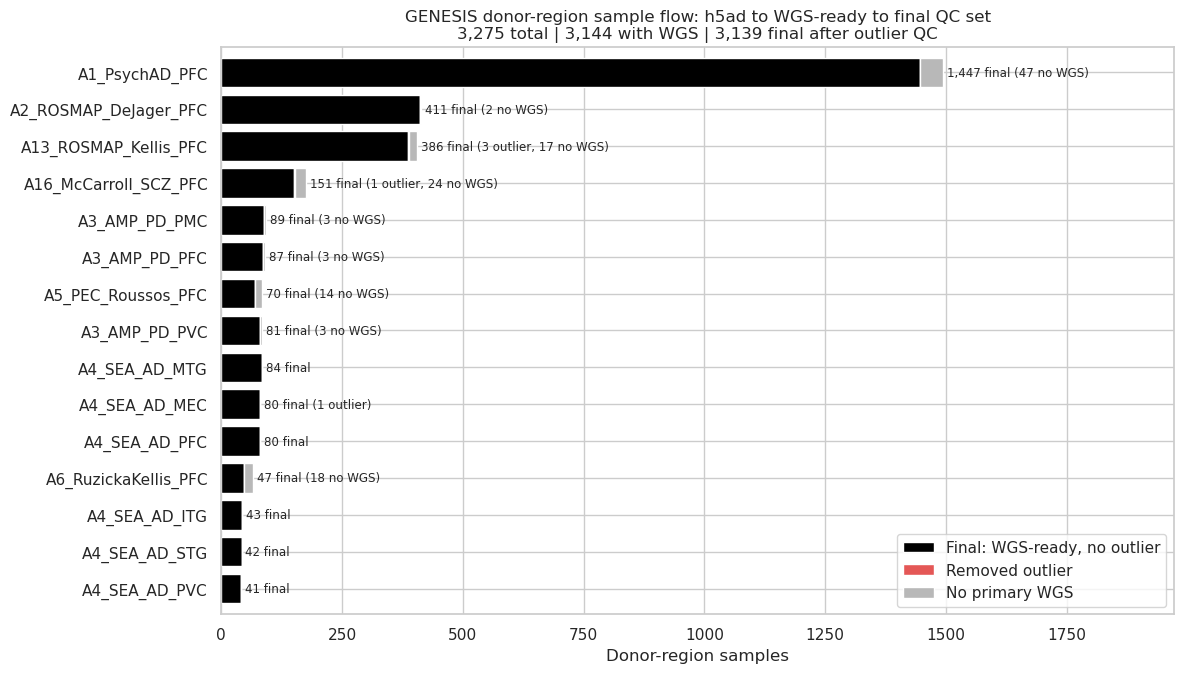

In [12]:
# Clean slide-ready summary: all h5ad donor-region samples -> WGS-ready -> final after outlier QC.
# Counts here are donor-region samples, not unique people across regions.

PSEUDOBULK_OUTPUTS_DIR = Path("/sc/arion/projects/CommonMind/genesis/pseudobulk_dreamlet_rc2/outputs")


def project_short_from_project(project):
    return str(project).replace("GEN_", "")


def clean_for_label(x):
    x = str(x)
    x = x.replace("GEN_", "")
    x = x.replace("GEN ", "")
    x = x.replace("-", "_")
    x = x.replace(" ", "_")
    return x


def infer_region_from_file_label(file_label, default="PFC"):
    file_label = str(file_label)
    known_regions = ["PFC", "PMC", "PVC", "MTG", "MEC", "ITG", "STG"]
    for region in known_regions:
        if file_label.endswith("_" + region):
            return region
    return default


def cohort_region_from_summary_row(row):
    project = project_short_from_project(row["project"])
    cohort = clean_for_label(row["cohort"])
    region = infer_region_from_file_label(row["file_label"])
    return f"{project}_{cohort}_{region}"


def cohort_region_from_output_dir(path):
    name = Path(path).name
    name = name.replace("GEN_", "")
    name = name.replace("-", "_")
    return name


if "donor_primary_gt_summary" not in globals() or donor_primary_gt_summary.empty:
    raise ValueError("Run the Primary Genotype / WGS Availability section first.")

if "donor_primary_gt" not in globals() or donor_primary_gt.empty:
    raise ValueError("Run the Primary Genotype / WGS Availability section first.")

# Starting and WGS-ready counts from the actual h5ad donor table.
sample_flow = donor_primary_gt_summary.copy()
sample_flow["cohort_region"] = sample_flow.apply(cohort_region_from_summary_row, axis=1)
sample_flow["starting_samples"] = sample_flow["n_h5ad_donors"].astype(int)
sample_flow["with_wgs"] = sample_flow["n_donors_with_primary_genotype"].astype(int)
sample_flow["without_wgs"] = sample_flow["starting_samples"] - sample_flow["with_wgs"]

# Read class-level outlier donor IDs from pseudobulk output folders.
outlier_frames = []
for exclude_path in sorted(PSEUDOBULK_OUTPUTS_DIR.glob("*/outliers/*_class_excludeIDs.txt")):
    output_dir = exclude_path.parents[1]
    cohort_region = cohort_region_from_output_dir(output_dir)
    ids = [x.strip() for x in exclude_path.read_text().splitlines() if x.strip()]
    for donor_id in ids:
        outlier_frames.append({
            "cohort_region": cohort_region,
            "donor_id": donor_id,
            "exclude_file": str(exclude_path),
        })

outlier_df = pd.DataFrame(outlier_frames)
if outlier_df.empty:
    outlier_df = pd.DataFrame(columns=["cohort_region", "donor_id", "exclude_file"])

# WGS-ready donor-region rows from the h5ad join, then remove outliers.
wgs_donor_region = donor_primary_gt.loc[
    donor_primary_gt["primary_genotype"].notna(),
    ["project", "cohort", "file_label", "donor_id", "primary_genotype"],
].drop_duplicates().copy()
wgs_donor_region["cohort_region"] = wgs_donor_region.apply(cohort_region_from_summary_row, axis=1)

wgs_with_outlier_flag = wgs_donor_region.merge(
    outlier_df[["cohort_region", "donor_id"]].drop_duplicates(),
    on=["cohort_region", "donor_id"],
    how="left",
    indicator=True,
)
wgs_with_outlier_flag["is_outlier"] = wgs_with_outlier_flag["_merge"].eq("both")

final_donor_region = wgs_with_outlier_flag.loc[~wgs_with_outlier_flag["is_outlier"]].copy()

final_counts = (
    final_donor_region
    .groupby("cohort_region", dropna=False)
    .agg(final_after_wgs_and_outlier_qc=("donor_id", "nunique"))
    .reset_index()
)

outlier_counts = (
    wgs_with_outlier_flag
    .groupby("cohort_region", dropna=False)
    .agg(outliers_removed=("is_outlier", "sum"))
    .reset_index()
)

sample_flow = sample_flow.merge(final_counts, on="cohort_region", how="left")
sample_flow = sample_flow.merge(outlier_counts, on="cohort_region", how="left")
sample_flow["final_after_wgs_and_outlier_qc"] = sample_flow["final_after_wgs_and_outlier_qc"].fillna(0).astype(int)
sample_flow["outliers_removed"] = sample_flow["outliers_removed"].fillna(0).astype(int)
sample_flow["pct_with_wgs"] = (100 * sample_flow["with_wgs"] / sample_flow["starting_samples"]).round(1)
sample_flow["pct_final"] = (100 * sample_flow["final_after_wgs_and_outlier_qc"] / sample_flow["starting_samples"]).round(1)

sample_flow_display = sample_flow[[
    "project", "cohort", "file_label", "cohort_region",
    "starting_samples", "with_wgs", "without_wgs",
    "outliers_removed", "final_after_wgs_and_outlier_qc",
    "pct_with_wgs", "pct_final",
]].sort_values(["project", "file_label"]).copy()

sample_flow_display.to_csv(OUTDIR / "slide_sample_flow_wgs_outlier_summary.csv", index=False)
outlier_df.to_csv(OUTDIR / "slide_sample_flow_outlier_ids.csv", index=False)
final_donor_region.to_csv(OUTDIR / "slide_final_wgs_ready_no_outlier_donor_regions.csv", index=False)

overall_summary = pd.DataFrame({
    "stage": ["All h5ad donor-region samples", "With primary WGS genotype", "Final after outlier QC"],
    "n_donor_region_samples": [
        int(sample_flow_display["starting_samples"].sum()),
        int(sample_flow_display["with_wgs"].sum()),
        int(sample_flow_display["final_after_wgs_and_outlier_qc"].sum()),
    ],
})
overall_summary["label"] = overall_summary["n_donor_region_samples"].map(lambda x: f"{x:,}")

overall_unique = pd.DataFrame({
    "metric": ["Unique primary genotypes after outlier QC", "Unique donor IDs after outlier QC", "Outlier donor-region samples removed"],
    "n": [
        int(final_donor_region["primary_genotype"].nunique()),
        int(final_donor_region["donor_id"].nunique()),
        int(sample_flow_display["outliers_removed"].sum()),
    ],
})
overall_unique["n"] = overall_unique["n"].map(lambda x: f"{x:,}")

print("Overall sample flow")
display(overall_summary[["stage", "n_donor_region_samples"]])
print("Final unique counts")
display(overall_unique)
display(sample_flow_display)

# One clean slide-ready figure: stacked donor-region sample flow by dataset/region.
plot_df = sample_flow_display.sort_values("starting_samples", ascending=True).copy()
y = np.arange(len(plot_df))

fig_height = max(5.5, 0.36 * len(plot_df) + 1.5)
fig, ax = plt.subplots(figsize=(12, fig_height))

final_vals = plot_df["final_after_wgs_and_outlier_qc"].to_numpy()
outlier_vals = plot_df["outliers_removed"].to_numpy()
no_wgs_vals = plot_df["without_wgs"].to_numpy()

ax.barh(y, final_vals, color="#000000", label="Final: WGS-ready, no outlier")
ax.barh(y, outlier_vals, left=final_vals, color="#E45756", label="Removed outlier")
ax.barh(y, no_wgs_vals, left=final_vals + outlier_vals, color="#B8B8B8", label="No primary WGS")

for i, row in enumerate(plot_df.itertuples(index=False)):
    label = f"{row.final_after_wgs_and_outlier_qc:,} final"
    extras = []
    if row.outliers_removed > 0:
        extras.append(f"{row.outliers_removed} outlier")
    if row.without_wgs > 0:
        extras.append(f"{row.without_wgs} no WGS")
    if extras:
        label += " (" + ", ".join(extras) + ")"
    ax.text(row.starting_samples + 8, i, label, va="center", fontsize=8.5)

ax.set_yticks(y)
ax.set_yticklabels(plot_df["cohort_region"])
ax.set_xlabel("Donor-region samples")
ax.set_ylabel("")
ax.set_title(
    "GENESIS donor-region sample flow: h5ad to WGS-ready to final QC set\n"
    f"{overall_summary.loc[0, 'label']} total | "
    f"{overall_summary.loc[1, 'label']} with WGS | "
    f"{overall_summary.loc[2, 'label']} final after outlier QC"
)
ax.legend(loc="lower right", frameon=True)
ax.set_xlim(0, plot_df["starting_samples"].max() * 1.32)
ax.margins(y=0.02)
plt.tight_layout()
save_figure(fig, "slide_sample_flow_wgs_outliers_by_dataset_region")
plt.show()

## Combined Selected `.obs` Columns

Pull these columns from every file when available: `individualID`, `class`, `subclass`, `set`, `rep`, `brain_region`, and `Source`. Missing columns are filled with `NA`, except missing `brain_region`, which is filled as `No region`.

In [13]:
SELECTED_OBS_COLUMNS = ["individualID", "class", "subclass", "set", "rep", "brain_region", "Source"]

selected_obs_frames = []

for rec in H5AD_FILES:
    file_label = rec["file_label"]
    path = rec["path"]
    if not Path(path).exists():
        warnings.warn(f"Missing file: {path}")
        continue

    print(f"Reading selected obs columns: {file_label}")
    obs, _ = read_obs_only(path)

    tmp = pd.DataFrame(index=obs.index)
    for col in SELECTED_OBS_COLUMNS:
        if col in obs.columns:
            tmp[col] = obs[col].astype("string")
        elif col == "brain_region":
            tmp[col] = "PFC"
        else:
            tmp[col] = pd.NA

    tmp["project"] = rec["project"]
    tmp["cohort"] = rec["cohort"]
    tmp["file_label"] = rec["file_label"]
    tmp["cell_barcode"] = tmp.index.astype(str)

    selected_obs_frames.append(tmp.reset_index(drop=True))
    del obs, tmp
    gc.collect()

selected_obs = pd.concat(selected_obs_frames, ignore_index=True)

selected_obs = selected_obs[[
    "project", "cohort", "file_label", "cell_barcode",
    "individualID", "class", "subclass", "set", "rep", "brain_region", "Source",
]]

selected_obs.to_csv(OUTDIR / "selected_obs_columns_all_files.csv", index=False)
selected_obs.head()

Reading selected obs columns: GEN_A1
Reading selected obs columns: GEN_A2
Reading selected obs columns: GEN_A3_PFC
Reading selected obs columns: GEN_A3_PMC
Reading selected obs columns: GEN_A3_PVC
Reading selected obs columns: GEN_A4_ITG
Reading selected obs columns: GEN_A4_MEC
Reading selected obs columns: GEN_A4_MTG
Reading selected obs columns: GEN_A4_PFC
Reading selected obs columns: GEN_A4_PVC
Reading selected obs columns: GEN_A4_STG
Reading selected obs columns: GEN_A5
Reading selected obs columns: GEN_A6
Reading selected obs columns: GEN_A13
Reading selected obs columns: GEN_A16


/tmp/ipykernel_3572400/2045293450.py:33: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  selected_obs = pd.concat(selected_obs_frames, ignore_index=True)


,project,cohort,file_label,cell_barcode,individualID,class,subclass,set,rep,brain_region,Source
0,GEN_A1,PsychAD,GEN_A1,NPSAD_20201103_A2_cDNA_AAACCCAAGAGCATCG,AMPAD_MSSM_0000048992,IN,IN_MGE_PVALB_CHC,NPSAD_20201103_A,2,PFC,MSSM
1,GEN_A1,PsychAD,GEN_A1,NPSAD_20201103_A2_cDNA_AAACCCAAGATACCAA,AMPAD_HBCC_0000000027,Oligo,Oligo,NPSAD_20201103_A,2,PFC,HBCC
2,GEN_A1,PsychAD,GEN_A1,NPSAD_20201103_A2_cDNA_AAACCCAAGCAACAGC,AMPAD_MSSM_0000047108,Astro,Astro,NPSAD_20201103_A,2,PFC,MSSM
3,GEN_A1,PsychAD,GEN_A1,NPSAD_20201103_A2_cDNA_AAACCCAAGCAATAAC,AMPAD_MSSM_0000047108,Oligo,Oligo,NPSAD_20201103_A,2,PFC,MSSM
4,GEN_A1,PsychAD,GEN_A1,NPSAD_20201103_A2_cDNA_AAACCCAAGCACTAGG,AMPAD_MSSM_0000009374,Oligo,Oligo,NPSAD_20201103_A,2,PFC,MSSM


In [14]:
selected_obs_column_presence = (
    selected_obs
    .groupby(["project", "cohort", "file_label"], dropna=False)
    [SELECTED_OBS_COLUMNS]
    .agg(lambda x: x.notna().any())
    .reset_index()
)

selected_obs_column_presence.to_csv(OUTDIR / "selected_obs_column_presence.csv", index=False)
selected_obs_column_presence

,project,cohort,file_label,individualID,class,subclass,set,rep,brain_region,Source
0,GEN_A1,PsychAD,GEN_A1,True,True,True,True,True,True,True
1,GEN_A13,ROSMAP_Kellis,GEN_A13,True,True,True,False,False,True,True
2,GEN_A16,McCarroll_SCZ,GEN_A16,True,True,True,True,False,True,True
3,GEN_A2,ROSMAP_DeJager,GEN_A2,True,True,True,True,True,True,True
4,GEN_A3,AMP-PD,GEN_A3_PFC,True,True,True,True,True,True,True
5,GEN_A3,AMP-PD,GEN_A3_PMC,True,True,True,True,True,True,True
6,GEN_A3,AMP-PD,GEN_A3_PVC,True,True,True,True,True,True,True
7,GEN_A4,SEA-AD,GEN_A4_ITG,True,True,True,True,False,True,False
8,GEN_A4,SEA-AD,GEN_A4_MEC,True,True,True,True,False,True,False
9,GEN_A4,SEA-AD,GEN_A4_MTG,True,True,True,True,False,True,False


In [15]:
project_region_summary = (
    cell_metadata
    .groupby(["project", "cohort", "file_label", "brain_region"], dropna=False)
    .agg(
        n_nuclei=("donor_id", "size"),
        n_donors=("donor_id", "nunique"),
    )
    .reset_index()
    .sort_values(["project", "file_label", "brain_region"])
)

project_summary = (
    cell_metadata
    .groupby(["project", "cohort"], dropna=False)
    .agg(
        n_files=("file_label", "nunique"),
        n_regions=("brain_region", "nunique"),
        n_nuclei=("donor_id", "size"),
        n_donors=("donor_id", "nunique"),
    )
    .reset_index()
    .sort_values("project")
)

project_region_summary.to_csv(OUTDIR / "project_region_nuclei_donor_summary.csv", index=False)
project_summary.to_csv(OUTDIR / "project_nuclei_donor_summary.csv", index=False)

display(project_summary)
project_region_summary

,project,cohort,n_files,n_regions,n_nuclei,n_donors
0,GEN_A1,PsychAD,1,1,7480569,1494
1,GEN_A13,ROSMAP_Kellis,1,1,1254270,406
2,GEN_A16,McCarroll_SCZ,1,1,917743,176
3,GEN_A2,ROSMAP_DeJager,1,1,1472123,413
4,GEN_A3,AMP-PD,3,3,1391439,97
5,GEN_A4,SEA-AD,6,6,4348303,84
6,GEN_A5,PEC_Roussos,1,1,151793,84
7,GEN_A6,RuzickaKellis,1,1,506868,65


,project,cohort,file_label,brain_region,n_nuclei,n_donors
0,GEN_A1,PsychAD,GEN_A1,PFC,7480569,1494
1,GEN_A13,ROSMAP_Kellis,GEN_A13,PFC,1254270,406
2,GEN_A16,McCarroll_SCZ,GEN_A16,PFC,917743,176
3,GEN_A2,ROSMAP_DeJager,GEN_A2,PFC,1472123,413
4,GEN_A3,AMP-PD,GEN_A3_PFC,PFC,514129,90
5,GEN_A3,AMP-PD,GEN_A3_PMC,PMC,468520,92
6,GEN_A3,AMP-PD,GEN_A3_PVC,PVC,408790,84
7,GEN_A4,SEA-AD,GEN_A4_ITG,ITG,402054,43
8,GEN_A4,SEA-AD,GEN_A4_MEC,MEC,928287,81
9,GEN_A4,SEA-AD,GEN_A4_MTG,MTG,1102490,84


In [16]:
donor_region_summary = (
    cell_metadata
    .drop_duplicates(["project", "cohort", "file_label", "brain_region", "donor_id"])
    .groupby(["project", "cohort", "file_label", "donor_id"], dropna=False)
    .agg(
        n_regions=("brain_region", "nunique"),
        regions=("brain_region", lambda x: ";".join(sorted(map(str, pd.Series(x).dropna().unique())))),
    )
    .reset_index()
    .sort_values(["project", "file_label", "donor_id"])
)

donor_region_summary.to_csv(OUTDIR / "donor_region_membership_summary.csv", index=False)
donor_region_summary.head()

,project,cohort,file_label,donor_id,n_regions,regions
0,GEN_A1,PsychAD,GEN_A1,AMPAD_HBCC_0000000002,1,PFC
1,GEN_A1,PsychAD,GEN_A1,AMPAD_HBCC_0000000003,1,PFC
2,GEN_A1,PsychAD,GEN_A1,AMPAD_HBCC_0000000004,1,PFC
3,GEN_A1,PsychAD,GEN_A1,AMPAD_HBCC_0000000005,1,PFC
4,GEN_A1,PsychAD,GEN_A1,AMPAD_HBCC_0000000006,1,PFC


## Visuals

Saved: outputs/h5ad_metadata_qc/project_region_nuclei_donor_bars.png
Saved: outputs/h5ad_metadata_qc/project_region_nuclei_donor_bars.pdf


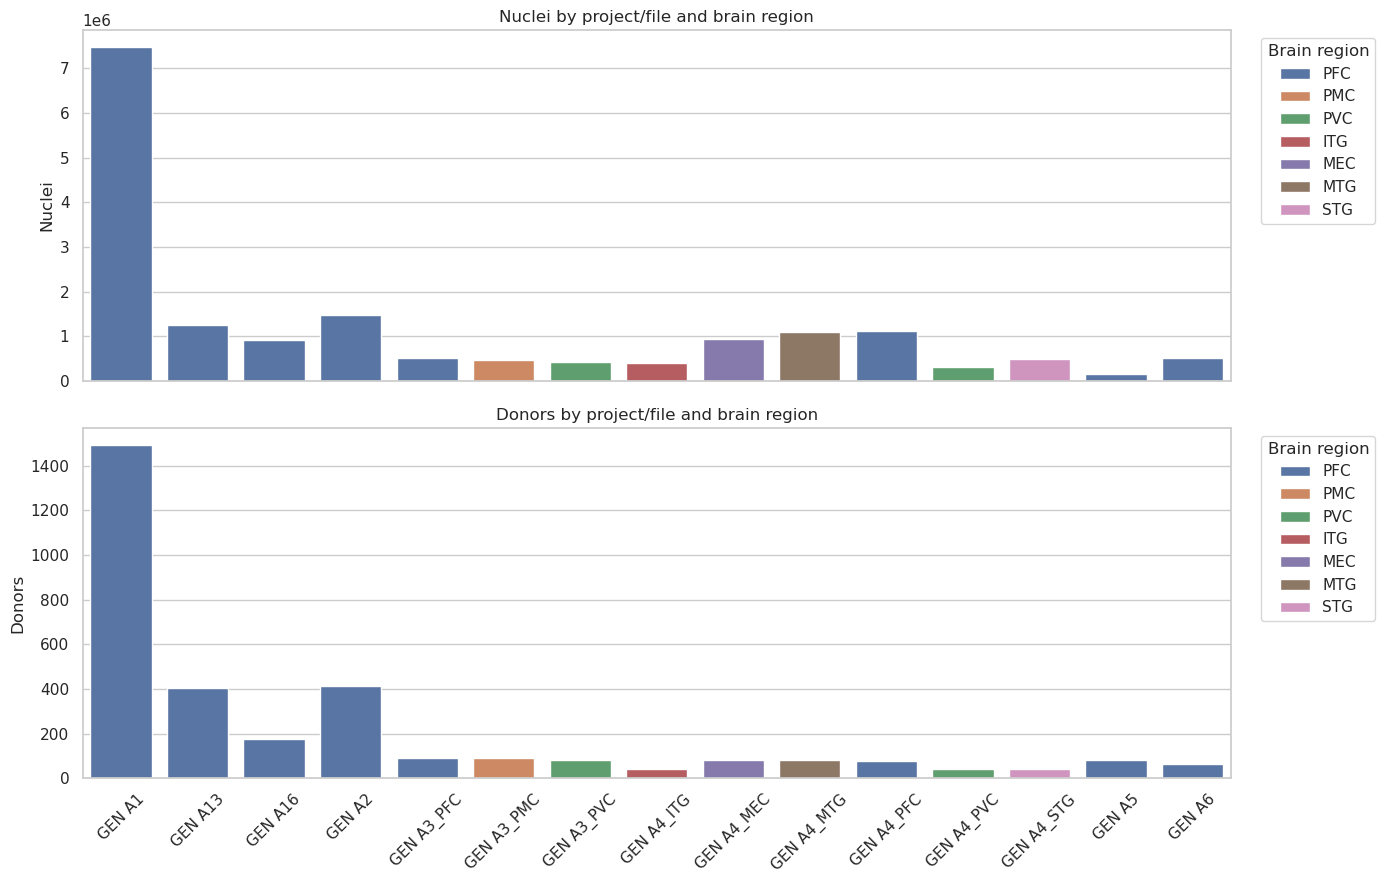

In [17]:
plot_df = project_region_summary.copy()
plot_df["project_file"] = np.where(
    plot_df["project"].isin(["GEN_A3", "GEN_A4"]),
    plot_df["file_label"],
    plot_df["project"],
)
plot_df["project_file_display"] = plot_df["project_file"].str.replace("GEN_", "GEN ", regex=False)

order = plot_df.sort_values(["project", "file_label", "brain_region"])["project_file_display"].drop_duplicates()

fig, axes = plt.subplots(2, 1, figsize=(14, 9), sharex=True)

sns.barplot(data=plot_df, x="project_file_display", y="n_nuclei", hue="brain_region", order=order, ax=axes[0])
axes[0].set_title("Nuclei by project/file and brain region")
axes[0].set_xlabel("")
axes[0].set_ylabel("Nuclei")
axes[0].legend(title="Brain region", bbox_to_anchor=(1.02, 1), loc="upper left")

sns.barplot(data=plot_df, x="project_file_display", y="n_donors", hue="brain_region", order=order, ax=axes[1])
axes[1].set_title("Donors by project/file and brain region")
axes[1].set_xlabel("")
axes[1].set_ylabel("Donors")
axes[1].legend(title="Brain region", bbox_to_anchor=(1.02, 1), loc="upper left")
axes[1].tick_params(axis="x", rotation=45)

plt.tight_layout()
save_figure(fig, "project_region_nuclei_donor_bars")
plt.show()

## Optional: Cell Class/Subclass Composition

In [18]:
class_summary = (
    cell_metadata
    .dropna(subset=["class"])
    .groupby(["project", "cohort", "file_label", "brain_region", "class"], dropna=False)
    .agg(
        n_nuclei=("donor_id", "size"),
        n_donors=("donor_id", "nunique"),
    )
    .reset_index()
    .sort_values(["project", "file_label", "brain_region", "class"])
)

subclass_summary = (
    cell_metadata
    .dropna(subset=["subclass"])
    .groupby(["project", "cohort", "file_label", "brain_region", "subclass"], dropna=False)
    .agg(
        n_nuclei=("donor_id", "size"),
        n_donors=("donor_id", "nunique"),
    )
    .reset_index()
    .sort_values(["project", "file_label", "brain_region", "subclass"])
)

class_summary.to_csv(OUTDIR / "project_region_class_summary.csv", index=False)
subclass_summary.to_csv(OUTDIR / "project_region_subclass_summary.csv", index=False)

display(class_summary.head(20))
display(subclass_summary.head(20))

,project,cohort,file_label,brain_region,class,n_nuclei,n_donors
0,GEN_A1,PsychAD,GEN_A1,PFC,Astro,945960,1494
1,GEN_A1,PsychAD,GEN_A1,PFC,EN,1473625,1493
2,GEN_A1,PsychAD,GEN_A1,PFC,IN,1160237,1494
3,GEN_A1,PsychAD,GEN_A1,PFC,Immune,378485,1489
4,GEN_A1,PsychAD,GEN_A1,PFC,OPC,473178,1494
5,GEN_A1,PsychAD,GEN_A1,PFC,Oligo,2866921,1493
6,GEN_A1,PsychAD,GEN_A1,PFC,Vascular,182163,1463
7,GEN_A13,ROSMAP_Kellis,GEN_A13,PFC,Astro,101260,397
8,GEN_A13,ROSMAP_Kellis,GEN_A13,PFC,EN,435298,398
9,GEN_A13,ROSMAP_Kellis,GEN_A13,PFC,IN,169311,398


,project,cohort,file_label,brain_region,subclass,n_nuclei,n_donors
0,GEN_A1,PsychAD,GEN_A1,PFC,Adaptive_Immune,15316,1254
1,GEN_A1,PsychAD,GEN_A1,PFC,Astro,945960,1494
2,GEN_A1,PsychAD,GEN_A1,PFC,EN_L2-3_IT,544734,1488
3,GEN_A1,PsychAD,GEN_A1,PFC,EN_L3-5_IT_1,174809,1475
4,GEN_A1,PsychAD,GEN_A1,PFC,EN_L3-5_IT_2,249888,1471
5,GEN_A1,PsychAD,GEN_A1,PFC,EN_L3-5_IT_3,240538,1463
6,GEN_A1,PsychAD,GEN_A1,PFC,EN_L5-6_NP,45205,1390
7,GEN_A1,PsychAD,GEN_A1,PFC,EN_L5_ET,1437,616
8,GEN_A1,PsychAD,GEN_A1,PFC,EN_L6B,45159,1380
9,GEN_A1,PsychAD,GEN_A1,PFC,EN_L6_CT,62673,1421


In [23]:
# Keep only donor/file/region combinations with a curated primary genotype,
# then remove class-level pseudobulk outliers.

PSEUDOBULK_OUTPUTS_DIR = Path("/sc/arion/projects/CommonMind/genesis/pseudobulk_dreamlet_rc2/outputs")

def cohort_region_from_output_dir(path):
    name = Path(path).name
    name = name.replace("GEN_", "")
    name = name.replace("-", "_")
    return name

wgs_ready_donors = (
    donor_primary_gt
    .loc[
        donor_primary_gt["primary_genotype"].notna(),
        ["project", "cohort", "file_label", "donor_id", "primary_genotype"],
    ]
    .drop_duplicates()
)

cell_metadata_wgs = cell_metadata.merge(
    wgs_ready_donors,
    on=["project", "cohort", "file_label", "donor_id"],
    how="inner",
)

cell_metadata_wgs["cohort_region_label"] = cell_metadata_wgs.apply(cohort_region_label, axis=1)

outlier_rows = []
for exclude_path in sorted(PSEUDOBULK_OUTPUTS_DIR.glob("*/outliers/*_class_excludeIDs.txt")):
    cohort_region = cohort_region_from_output_dir(exclude_path.parents[1])
    ids = [x.strip() for x in exclude_path.read_text().splitlines() if x.strip()]
    for donor_id in ids:
        outlier_rows.append({
            "cohort_region_label": cohort_region,
            "donor_id": donor_id,
            "exclude_file": str(exclude_path),
        })

outlier_df = pd.DataFrame(outlier_rows)

if len(outlier_df):
    cell_metadata_wgs = cell_metadata_wgs.merge(
        outlier_df[["cohort_region_label", "donor_id"]].drop_duplicates(),
        on=["cohort_region_label", "donor_id"],
        how="left",
        indicator=True,
    )
    cell_metadata_wgs["is_outlier"] = cell_metadata_wgs["_merge"].eq("both")

    print("Outlier donor-region samples removed:")
    display(
        outlier_df
        .groupby("cohort_region_label", dropna=False)
        .agg(n_outliers=("donor_id", "nunique"),
             outlier_ids=("donor_id", lambda x: "; ".join(sorted(set(x)))))
        .reset_index()
    )

    cell_metadata_wgs = (
        cell_metadata_wgs
        .loc[~cell_metadata_wgs["is_outlier"]]
        .drop(columns=["_merge", "is_outlier"])
    )
else:
    print("No outlier exclude files found.")

print("Final WGS-ready, no-outlier donor-region samples:",
      cell_metadata_wgs.drop_duplicates(["cohort_region_label", "donor_id"]).shape[0])
print("Final unique primary genotypes:",
      cell_metadata_wgs["primary_genotype"].nunique())

Outlier donor-region samples removed:


,cohort_region_label,n_outliers,outlier_ids
0,A13_ROSMAP_Kellis_PFC,3,R5693901; R5850046; R7208968
1,A16_McCarroll_SCZ_PFC,1,S14741
2,A4_SEA_AD_MEC,1,H21.33.020


Final WGS-ready, no-outlier donor-region samples: 3139
Final unique primary genotypes: 2420


## Manuscript / Presentation Figures

Save publication- and conference-ready summaries as both `.png` and `.pdf`.


Outlier donor-region samples removed:


,cohort_region_label,n_outliers,outlier_ids
0,A13_ROSMAP_Kellis_PFC,3,R5693901; R5850046; R7208968
1,A16_McCarroll_SCZ_PFC,1,S14741
2,A4_SEA_AD_MEC,1,H21.33.020


Final WGS-ready, no-outlier donor-region samples: 3139
Final unique primary genotypes: 2420
Saved: outputs/h5ad_metadata_qc/manuscript_final_wgs_no_outlier_donors_by_dataset_region.png
Saved: outputs/h5ad_metadata_qc/manuscript_final_wgs_no_outlier_donors_by_dataset_region.pdf


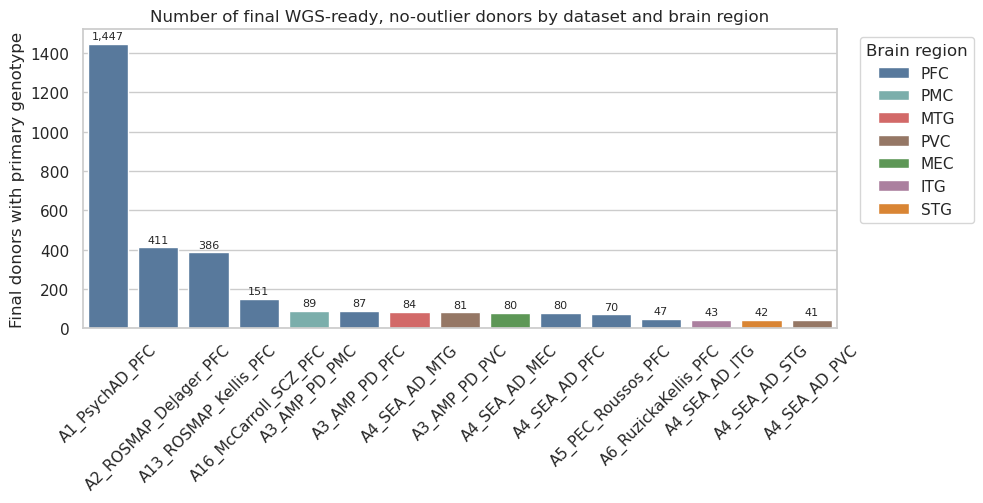

Saved: outputs/h5ad_metadata_qc/manuscript_final_wgs_no_outlier_nuclei_by_dataset_region.png
Saved: outputs/h5ad_metadata_qc/manuscript_final_wgs_no_outlier_nuclei_by_dataset_region.pdf


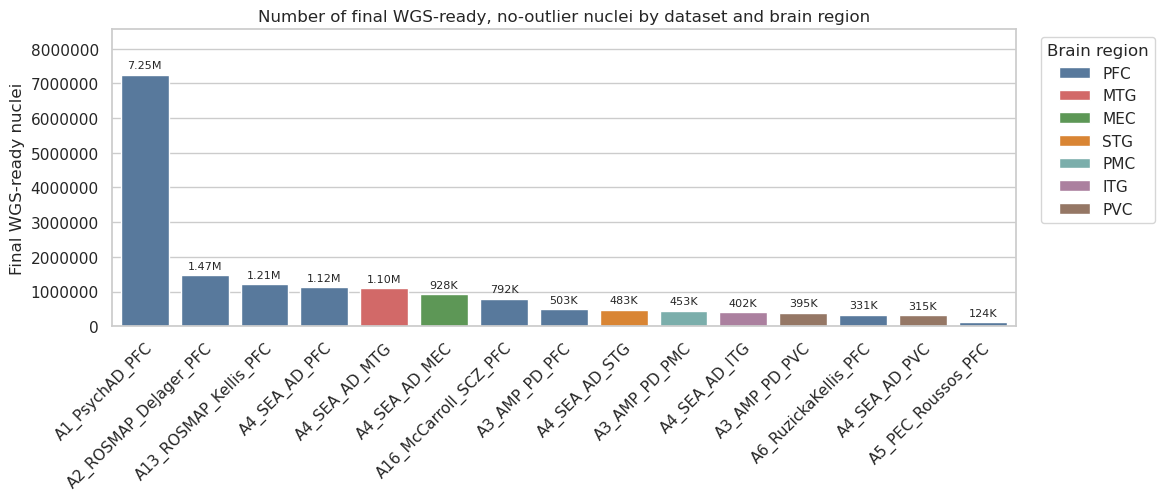

Saved: outputs/h5ad_metadata_qc/manuscript_final_wgs_no_outlier_nuclei_per_donor_distribution.png
Saved: outputs/h5ad_metadata_qc/manuscript_final_wgs_no_outlier_nuclei_per_donor_distribution.pdf


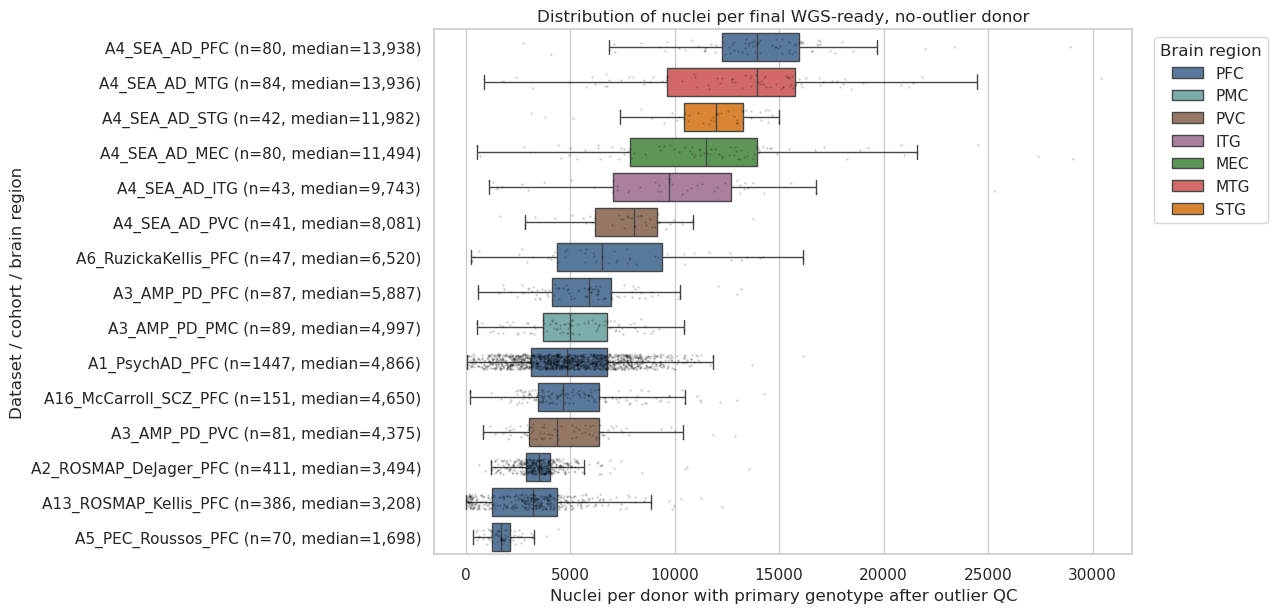

,Project,Cohort,File / region,N,With WGS,w/o WGS,Outliers,Final,% Final
0,A1,PsychAD,GEN_A1,1494,1447,47,0,1447,96.9
1,A13,ROSMAP_Kellis,GEN_A13,406,389,17,3,386,95.1
2,A16,McCarroll_SCZ,GEN_A16,176,152,24,1,151,85.8
3,A2,ROSMAP_DeJager,GEN_A2,413,411,2,0,411,99.5
4,A3,AMP-PD,GEN_A3_PFC,90,87,3,0,87,96.7
5,A3,AMP-PD,GEN_A3_PMC,92,89,3,0,89,96.7
6,A3,AMP-PD,GEN_A3_PVC,84,81,3,0,81,96.4
7,A4,SEA-AD,GEN_A4_ITG,43,43,0,0,43,100.0
8,A4,SEA-AD,GEN_A4_MEC,81,81,0,1,80,98.8
9,A4,SEA-AD,GEN_A4_MTG,84,84,0,0,84,100.0


Saved: outputs/h5ad_metadata_qc/pseudobulk_donor_to_wgs_final_qc_table.png
Saved: outputs/h5ad_metadata_qc/pseudobulk_donor_to_wgs_final_qc_table.pdf


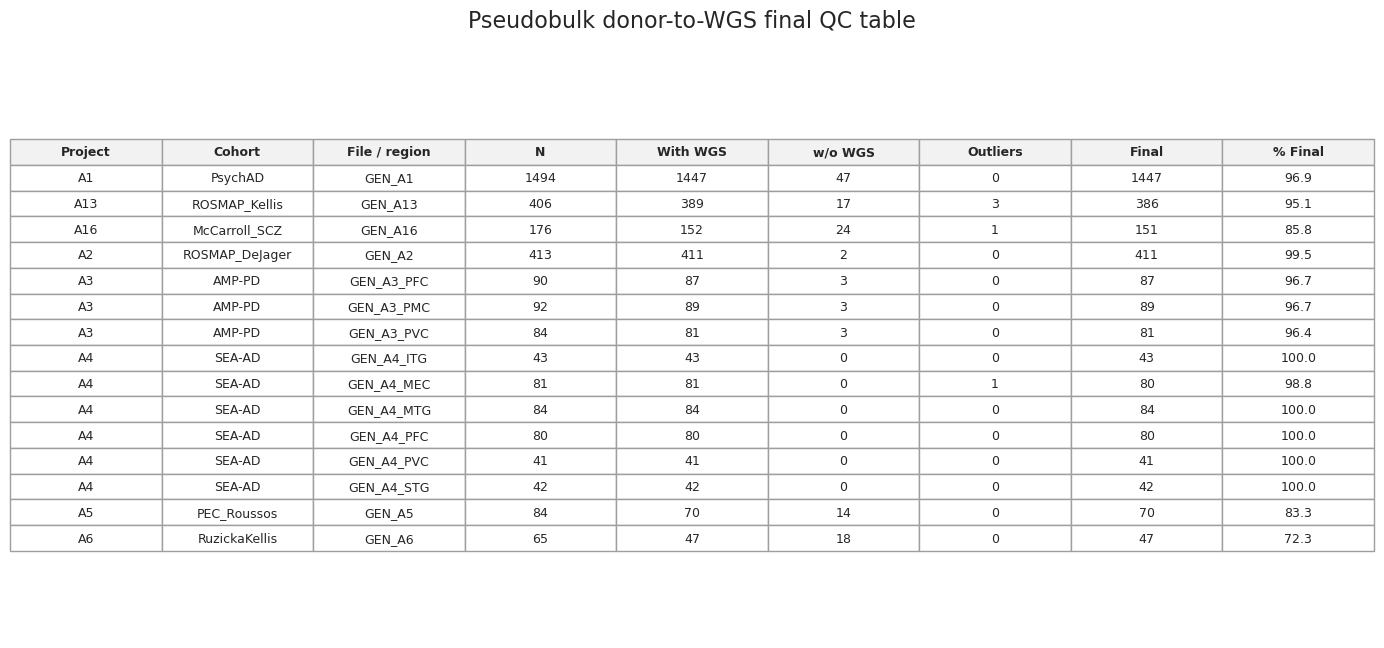

In [24]:
def clean_label_text(x):
    x = str(x)
    x = x.replace("GEN_", "")
    x = x.replace(" ", "_")
    x = x.replace("-", "_")
    return x


def cohort_region_label(row):
    project = clean_label_text(row["project"])
    cohort = clean_label_text(row["cohort"])
    region = clean_label_text(row["brain_region"])
    return f"{project}_{cohort}_{region}"


def cohort_region_from_output_dir(path):
    name = Path(path).name
    name = name.replace("GEN_", "")
    name = name.replace("-", "_")
    return name


def comma_int(x):
    return f"{int(round(x)):,}"


def compact_count(x):
    x = float(x)
    if x >= 1_000_000:
        return f"{x / 1_000_000:.2f}M"
    if x >= 1_000:
        return f"{x / 1_000:.0f}K"
    return f"{x:.0f}"


region_palette = {
    "PFC": "#4C78A8",
    "PMC": "#72B7B2",
    "PVC": "#9D755D",
    "MTG": "#E45756",
    "MEC": "#54A24B",
    "ITG": "#B279A2",
    "STG": "#F58518",
}

PSEUDOBULK_OUTPUTS_DIR = Path("/sc/arion/projects/CommonMind/genesis/pseudobulk_dreamlet_rc2/outputs")

if "donor_primary_gt" not in globals() or not len(donor_primary_gt):
    raise ValueError("Run the Primary Genotype / WGS Availability section before this plotting cell.")

# Build WGS-ready donor-region set.
wgs_ready_donors = (
    donor_primary_gt
    .loc[
        donor_primary_gt["primary_genotype"].notna(),
        ["project", "cohort", "file_label", "donor_id", "primary_genotype"],
    ]
    .drop_duplicates()
)

cell_metadata_wgs = cell_metadata.merge(
    wgs_ready_donors,
    on=["project", "cohort", "file_label", "donor_id"],
    how="inner",
)

cell_metadata_wgs["cohort_region_label"] = cell_metadata_wgs.apply(cohort_region_label, axis=1)

# Remove class-level pseudobulk outlier donor-region samples.
outlier_rows = []
for exclude_path in sorted(PSEUDOBULK_OUTPUTS_DIR.glob("*/outliers/*_class_excludeIDs.txt")):
    cohort_region = cohort_region_from_output_dir(exclude_path.parents[1])
    ids = [x.strip() for x in exclude_path.read_text().splitlines() if x.strip()]
    for donor_id in ids:
        outlier_rows.append({
            "cohort_region_label": cohort_region,
            "donor_id": donor_id,
            "exclude_file": str(exclude_path),
        })

outlier_df = pd.DataFrame(outlier_rows)

if len(outlier_df):
    outlier_keys = outlier_df[["cohort_region_label", "donor_id"]].drop_duplicates()

    cell_metadata_wgs = cell_metadata_wgs.merge(
        outlier_keys,
        on=["cohort_region_label", "donor_id"],
        how="left",
        indicator=True,
    )
    cell_metadata_wgs["is_outlier"] = cell_metadata_wgs["_merge"].eq("both")

    print("Outlier donor-region samples removed:")
    display(
        outlier_df
        .groupby("cohort_region_label", dropna=False)
        .agg(
            n_outliers=("donor_id", "nunique"),
            outlier_ids=("donor_id", lambda x: "; ".join(sorted(set(x)))),
        )
        .reset_index()
    )

    cell_metadata_wgs = (
        cell_metadata_wgs
        .loc[~cell_metadata_wgs["is_outlier"]]
        .drop(columns=["_merge", "is_outlier"])
    )
else:
    print("No outlier exclude files found.")

print(
    "Final WGS-ready, no-outlier donor-region samples:",
    cell_metadata_wgs.drop_duplicates(["cohort_region_label", "donor_id"]).shape[0],
)
print(
    "Final unique primary genotypes:",
    cell_metadata_wgs["primary_genotype"].nunique(),
)

# One row per project/file/region for final manuscript-scale plots.
plot_scale_wgs = (
    cell_metadata_wgs
    .groupby(["project", "cohort", "file_label", "brain_region"], dropna=False)
    .agg(
        n_nuclei=("donor_id", "size"),
        n_donors=("donor_id", "nunique"),
        n_primary_genotypes=("primary_genotype", "nunique"),
    )
    .reset_index()
)

plot_scale_wgs["cohort_region_label"] = plot_scale_wgs.apply(cohort_region_label, axis=1)
plot_scale_wgs = plot_scale_wgs.sort_values("n_donors", ascending=False)
plot_scale_wgs_nuclei = plot_scale_wgs.sort_values("n_nuclei", ascending=False)

label_order_donors = plot_scale_wgs["cohort_region_label"].tolist()
label_order_nuclei = plot_scale_wgs_nuclei["cohort_region_label"].tolist()

plot_scale_wgs.to_csv(
    OUTDIR / "final_wgs_no_outlier_project_region_nuclei_donor_summary.csv",
    index=False,
)

# Plot 1: final donors by dataset/region.
fig, ax = plt.subplots(figsize=(max(10, 0.5 * len(plot_scale_wgs)), 5.2))

sns.barplot(
    data=plot_scale_wgs,
    x="cohort_region_label",
    y="n_donors",
    hue="brain_region",
    order=label_order_donors,
    palette=region_palette,
    dodge=False,
    ax=ax,
)

for container in ax.containers:
    ax.bar_label(
        container,
        labels=[comma_int(v.get_height()) if v.get_height() > 0 else "" for v in container],
        padding=2,
        fontsize=8,
    )

ax.set_title("Number of final WGS-ready, no-outlier donors by dataset and brain region")
ax.set_xlabel("")
ax.set_ylabel("Final donors with primary genotype")
ax.tick_params(axis="x", rotation=45)
ax.legend(title="Brain region", bbox_to_anchor=(1.02, 1), loc="upper left")
plt.tight_layout()
save_figure(fig, "manuscript_final_wgs_no_outlier_donors_by_dataset_region")
plt.show()

# Plot 2: final nuclei by dataset/region.
fig, ax = plt.subplots(figsize=(max(13, 0.7 * len(plot_scale_wgs_nuclei)), 5.6))

sns.barplot(
    data=plot_scale_wgs_nuclei,
    x="cohort_region_label",
    y="n_nuclei",
    hue="brain_region",
    order=label_order_nuclei,
    palette=region_palette,
    dodge=False,
    ax=ax,
)

for container in ax.containers:
    ax.bar_label(
        container,
        labels=[compact_count(v.get_height()) if v.get_height() > 0 else "" for v in container],
        padding=3,
        fontsize=8,
    )

ax.set_title("Number of final WGS-ready, no-outlier nuclei by dataset and brain region")
ax.set_xlabel("")
ax.set_ylabel("Final WGS-ready nuclei")
ax.ticklabel_format(axis="y", style="plain")
ax.set_ylim(0, plot_scale_wgs_nuclei["n_nuclei"].max() * 1.18)

ax.tick_params(axis="x", rotation=45)
for label in ax.get_xticklabels():
    label.set_ha("right")
    label.set_rotation_mode("anchor")

ax.legend(title="Brain region", bbox_to_anchor=(1.02, 1), loc="upper left")
ax.margins(x=0.01)
fig.subplots_adjust(bottom=0.35, right=0.82)

save_figure(fig, "manuscript_final_wgs_no_outlier_nuclei_by_dataset_region")
plt.show()

# Plot 3: final nuclei per donor distribution.
donor_nuclei_wgs = (
    cell_metadata_wgs
    .groupby(["project", "cohort", "file_label", "brain_region", "donor_id", "primary_genotype"], dropna=False)
    .size()
    .reset_index(name="nuclei_per_donor")
)

donor_nuclei_wgs["cohort_region_label"] = donor_nuclei_wgs.apply(cohort_region_label, axis=1)

donor_label_stats = (
    donor_nuclei_wgs
    .groupby("cohort_region_label", dropna=False)
    .agg(
        n_donors=("donor_id", "nunique"),
        median_nuclei=("nuclei_per_donor", "median"),
    )
    .reset_index()
)

donor_label_stats["display_label"] = donor_label_stats.apply(
    lambda r: f"{r['cohort_region_label']} (n={int(r['n_donors'])}, median={int(round(r['median_nuclei'])):,})",
    axis=1,
)

label_map = dict(zip(donor_label_stats["cohort_region_label"], donor_label_stats["display_label"]))
donor_nuclei_wgs["display_label"] = donor_nuclei_wgs["cohort_region_label"].map(label_map)
box_order = donor_label_stats.sort_values("median_nuclei", ascending=False)["display_label"].tolist()

fig, ax = plt.subplots(figsize=(13, max(5, 0.42 * len(box_order))))

sns.boxplot(
    data=donor_nuclei_wgs,
    y="display_label",
    x="nuclei_per_donor",
    hue="brain_region",
    order=box_order,
    palette=region_palette,
    dodge=False,
    showfliers=False,
    ax=ax,
)

sns.stripplot(
    data=donor_nuclei_wgs,
    y="display_label",
    x="nuclei_per_donor",
    order=box_order,
    color="black",
    alpha=0.22,
    size=1.6,
    jitter=0.22,
    ax=ax,
)

ax.set_title("Distribution of nuclei per final WGS-ready, no-outlier donor")
ax.set_xlabel("Nuclei per donor with primary genotype after outlier QC")
ax.set_ylabel("Dataset / cohort / brain region")
ax.legend(title="Brain region", bbox_to_anchor=(1.02, 1), loc="upper left")
plt.tight_layout()
save_figure(fig, "manuscript_final_wgs_no_outlier_nuclei_per_donor_distribution")
plt.show()

donor_nuclei_wgs.to_csv(
    OUTDIR / "final_wgs_no_outlier_donor_nuclei_per_dataset_region.csv",
    index=False,
)

# Final donor-to-WGS/outlier table.
final_table = (
    plot_scale_wgs
    .groupby(["project", "cohort", "file_label"], dropna=False)
    .agg(final_after_outlier_qc=("n_donors", "sum"))
    .reset_index()
)

wgs_table = donor_primary_gt_summary.copy()
wgs_table = wgs_table.merge(
    final_table,
    on=["project", "cohort", "file_label"],
    how="left",
)

wgs_table["final_after_outlier_qc"] = wgs_table["final_after_outlier_qc"].fillna(0).astype(int)
wgs_table["project_display"] = wgs_table["project"].str.replace("GEN_", "", regex=False)
wgs_table["without_wgs"] = wgs_table["n_h5ad_donors"] - wgs_table["n_donors_with_primary_genotype"]
wgs_table["outliers_removed"] = wgs_table["n_donors_with_primary_genotype"] - wgs_table["final_after_outlier_qc"]
wgs_table["pct_final"] = (
    100 * wgs_table["final_after_outlier_qc"] / wgs_table["n_h5ad_donors"]
).round(1)

wgs_table = wgs_table[[
    "project_display", "cohort", "file_label", "n_h5ad_donors",
    "n_donors_with_primary_genotype", "without_wgs",
    "outliers_removed", "final_after_outlier_qc", "pct_final",
]].sort_values(["project_display", "file_label"])

wgs_table.to_csv(OUTDIR / "pseudobulk_donor_to_wgs_final_qc_table.csv", index=False)

display_table = wgs_table.rename(columns={
    "project_display": "Project",
    "cohort": "Cohort",
    "file_label": "File / region",
    "n_h5ad_donors": "N",
    "n_donors_with_primary_genotype": "With WGS",
    "without_wgs": "w/o WGS",
    "outliers_removed": "Outliers",
    "final_after_outlier_qc": "Final",
    "pct_final": "% Final",
})

display(display_table)

fig_height = max(3.2, 0.35 * len(display_table) + 1.4)
fig, ax = plt.subplots(figsize=(14, fig_height))
ax.axis("off")

table = ax.table(
    cellText=display_table.values,
    colLabels=display_table.columns,
    loc="center",
    cellLoc="center",
    colLoc="center",
)

table.auto_set_font_size(False)
table.set_fontsize(9)
table.scale(1, 1.35)

for (row, col), cell in table.get_celld().items():
    cell.set_edgecolor("#9E9E9E")
    if row == 0:
        cell.set_text_props(weight="bold")
        cell.set_facecolor("#F2F2F2")

ax.set_title("Pseudobulk donor-to-WGS final QC table", fontsize=16, pad=18)
plt.tight_layout()
save_figure(fig, "pseudobulk_donor_to_wgs_final_qc_table")
plt.show()

Saved: outputs/h5ad_metadata_qc/sample_flow_total_wgs_final_samples_and_unique_donors_clean.png
Saved: outputs/h5ad_metadata_qc/sample_flow_total_wgs_final_samples_and_unique_donors_clean.pdf


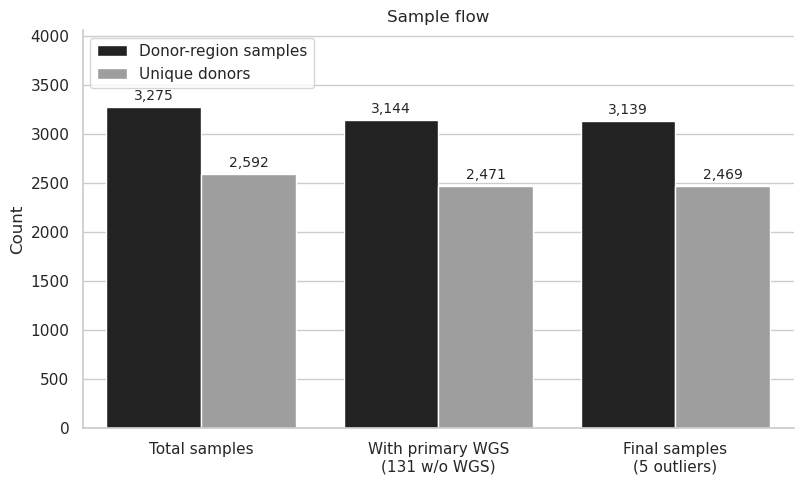

,stage,metric,n
0,Total samples,Donor-region samples,3275
1,Total samples,Unique donors,2592
2,With primary WGS\n(131 w/o WGS),Donor-region samples,3144
3,With primary WGS\n(131 w/o WGS),Unique donors,2471
4,Final samples\n(5 outliers),Donor-region samples,3139
5,Final samples\n(5 outliers),Unique donors,2469


In [41]:
# Clean three-stage summary: donor-region samples and unique donors side by side

total_samples = int(wgs_table["n_h5ad_donors"].sum())
with_wgs = int(wgs_table["n_donors_with_primary_genotype"].sum())
no_wgs = int(wgs_table["without_wgs"].sum())
final_samples = int(wgs_table["final_after_outlier_qc"].sum())
outliers = int(wgs_table["outliers_removed"].sum())

all_unique_donors = int(donor_primary_gt["donor_id"].nunique())

wgs_unique_donors = int(
    donor_primary_gt
    .loc[donor_primary_gt["primary_genotype"].notna(), "donor_id"]
    .nunique()
)

final_unique_donors = int(
    cell_metadata_wgs[["donor_id"]]
    .drop_duplicates()
    .shape[0]
)

summary_bar = pd.DataFrame({
    "stage": [
        "Total samples", "Total samples",
        f"With primary WGS\n({no_wgs:,} w/o WGS)", f"With primary WGS\n({no_wgs:,} w/o WGS)",
        f"Final samples\n({outliers:,} outliers)", f"Final samples\n({outliers:,} outliers)",
    ],
    "metric": [
        "Donor-region samples", "Unique donors",
        "Donor-region samples", "Unique donors",
        "Donor-region samples", "Unique donors",
    ],
    "n": [
        total_samples, all_unique_donors,
        with_wgs, wgs_unique_donors,
        final_samples, final_unique_donors,
    ],
})

fig, ax = plt.subplots(figsize=(8.2, 5.0))

sns.barplot(
    data=summary_bar,
    x="stage",
    y="n",
    hue="metric",
    palette={
        "Donor-region samples": "#222222",
        "Unique donors": "#9E9E9E",
    },
    ax=ax,
)

for container in ax.containers:
    ax.bar_label(
        container,
        labels=[f"{v.get_height():,.0f}" if v.get_height() > 0 else "" for v in container],
        padding=3,
        fontsize=10,
    )

ax.set_title("Sample flow")
ax.set_xlabel("")
ax.set_ylabel("Count")
ax.set_ylim(0, total_samples * 1.24)
ax.legend(title="", frameon=True, loc="upper left")
sns.despine(ax=ax)

plt.tight_layout()
save_figure(fig, "sample_flow_total_wgs_final_samples_and_unique_donors_clean")
plt.show()

summary_bar

Saved: outputs/h5ad_metadata_qc/manuscript_final_wgs_no_outlier_donors_and_nuclei_by_dataset_region.png
Saved: outputs/h5ad_metadata_qc/manuscript_final_wgs_no_outlier_donors_and_nuclei_by_dataset_region.pdf


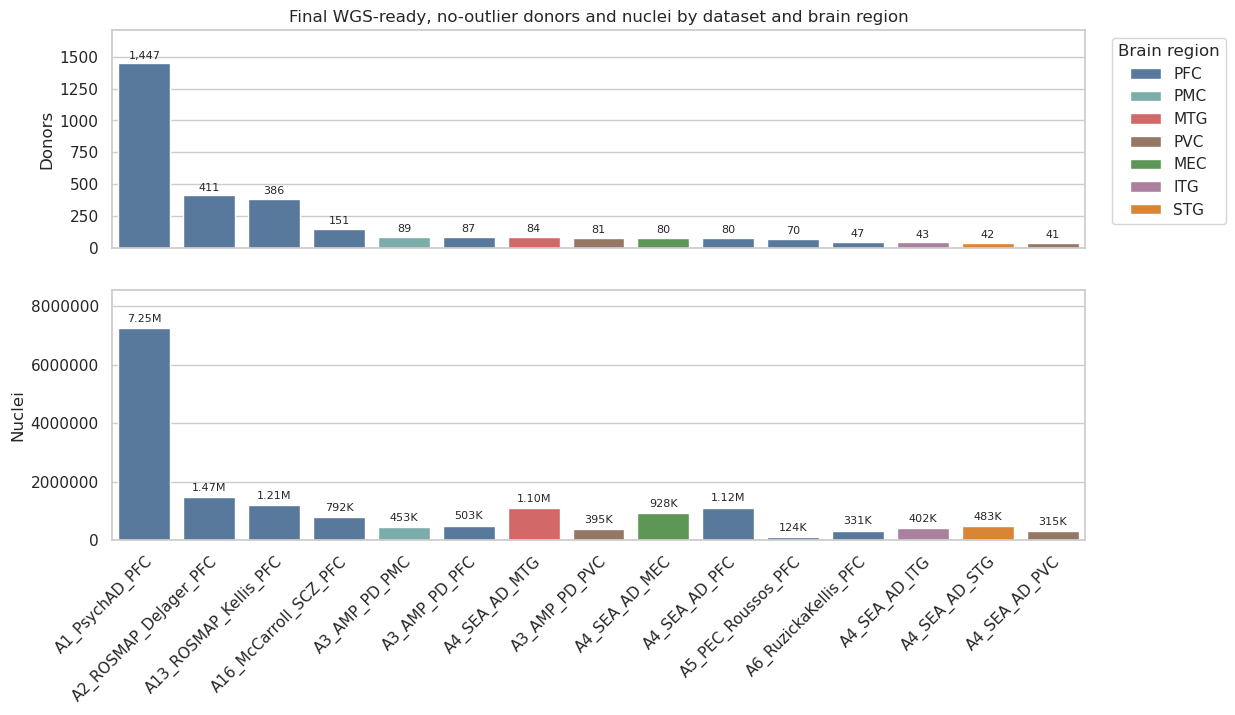

In [30]:
# Combined final WGS-ready no-outlier donors + nuclei by dataset/region

combined_plot = plot_scale_wgs.copy()
combined_plot = combined_plot.sort_values("n_donors", ascending=False)
combined_order = combined_plot["cohort_region_label"].tolist()

fig, axes = plt.subplots(
    2,
    1,
    figsize=(14, 8.5),
    sharex=True,
    gridspec_kw={"height_ratios": [1, 1.15]},
)

# Top: donors
sns.barplot(
    data=combined_plot,
    x="cohort_region_label",
    y="n_donors",
    hue="brain_region",
    order=combined_order,
    palette=region_palette,
    dodge=False,
    ax=axes[0],
)

for container in axes[0].containers:
    axes[0].bar_label(
        container,
        labels=[comma_int(v.get_height()) if v.get_height() > 0 else "" for v in container],
        padding=2,
        fontsize=8,
    )

axes[0].set_title("Final WGS-ready, no-outlier donors and nuclei by dataset and brain region")
axes[0].set_xlabel("")
axes[0].set_ylabel("Donors")
axes[0].legend(title="Brain region", bbox_to_anchor=(1.02, 1), loc="upper left")

# Bottom: nuclei
sns.barplot(
    data=combined_plot,
    x="cohort_region_label",
    y="n_nuclei",
    hue="brain_region",
    order=combined_order,
    palette=region_palette,
    dodge=False,
    ax=axes[1],
)

for container in axes[1].containers:
    axes[1].bar_label(
        container,
        labels=[compact_count(v.get_height()) if v.get_height() > 0 else "" for v in container],
        padding=3,
        fontsize=8,
    )

axes[1].set_xlabel("")
axes[1].set_ylabel("Nuclei")
axes[1].ticklabel_format(axis="y", style="plain")
axes[1].legend_.remove()

axes[1].tick_params(axis="x", rotation=45)
for label in axes[1].get_xticklabels():
    label.set_ha("right")
    label.set_rotation_mode("anchor")

axes[0].set_ylim(0, combined_plot["n_donors"].max() * 1.18)
axes[1].set_ylim(0, combined_plot["n_nuclei"].max() * 1.18)

fig.subplots_adjust(bottom=0.28, right=0.82, hspace=0.18)

save_figure(fig, "manuscript_final_wgs_no_outlier_donors_and_nuclei_by_dataset_region")
plt.show()

In [31]:
total_final_nuclei = int(cell_metadata_wgs.shape[0])
total_final_donor_region_samples = (
    cell_metadata_wgs
    .drop_duplicates(["cohort_region_label", "donor_id"])
    .shape[0]
)

print(f"{total_final_nuclei:,} nuclei from {total_final_donor_region_samples:,} donor-region samples")

16,872,844 nuclei from 3,139 donor-region samples


In [33]:
donor_demo_final = (
    cell_metadata_wgs
    .drop_duplicates(["cohort_region_label", "donor_id"])
    .copy()
)

## Job Planning Table

This table can feed pseudobulk job submission. I usually submit by `file_label x brain_region`, then let the R script handle class/subclass inside each job, or split further if memory/time becomes an issue.

In [34]:
demo_cols = ["donor_id", "primary_genotype", "genesis_id", "cohort", "brain_region", "sex", "ancestry"]

demo_from_primary_gt = (
    primary_gt
    .loc[primary_gt["primary_genotype"].notna(), [c for c in demo_cols if c in primary_gt.columns]]
    .drop_duplicates(["donor_id", "primary_genotype", "cohort", "brain_region"])
    .copy()
)

demo_from_primary_gt["project_short"] = demo_from_primary_gt["genesis_id"].map(clean_label_text)

cohort_pretty = {
    "psychad": "PsychAD",
    "rosmap": "ROSMAP_DeJager",
    "amppd": "AMP_PD",
    "seaad": "SEA_AD",
    "pec_cmc": "PEC_Roussos",
    "pec_szbd": "RuzickaKellis",
    "rosmap_kellis": "ROSMAP_Kellis",
    "pec_mccarroll": "McCarroll_SCZ",
}

demo_from_primary_gt["cohort_pretty"] = (
    demo_from_primary_gt["cohort"]
    .map(cohort_pretty)
    .fillna(demo_from_primary_gt["cohort"])
)

demo_from_primary_gt["cohort_region_label"] = (
    demo_from_primary_gt["project_short"] + "_" +
    demo_from_primary_gt["cohort_pretty"].map(clean_label_text) + "_" +
    demo_from_primary_gt["brain_region"].fillna("PFC")
)

demo_from_primary_gt = demo_from_primary_gt[
    ["cohort_region_label", "donor_id", "primary_genotype", "sex", "ancestry"]
].drop_duplicates(["cohort_region_label", "donor_id"])

donor_demo_final = (
    cell_metadata_wgs
    .drop_duplicates(["cohort_region_label", "donor_id", "primary_genotype"])
    [["cohort_region_label", "donor_id", "primary_genotype"]]
    .merge(
        demo_from_primary_gt,
        on=["cohort_region_label", "donor_id", "primary_genotype"],
        how="left",
    )
)

donor_demo_final["ancestry_clean"] = donor_demo_final["ancestry"].map(clean_ancestry)
donor_demo_final["sex_clean"] = (
    donor_demo_final["sex"]
    .fillna("Unknown")
    .replace("", "Unknown")
)


Non-European final donor-region samples: 539
PsychAD non-European donor-region samples: 490
Outside PsychAD: 49
Percent in PsychAD: 90.9
Saved: outputs/h5ad_metadata_qc/final_wgs_no_outlier_ancestry_and_sex_by_dataset_region.png
Saved: outputs/h5ad_metadata_qc/final_wgs_no_outlier_ancestry_and_sex_by_dataset_region.pdf


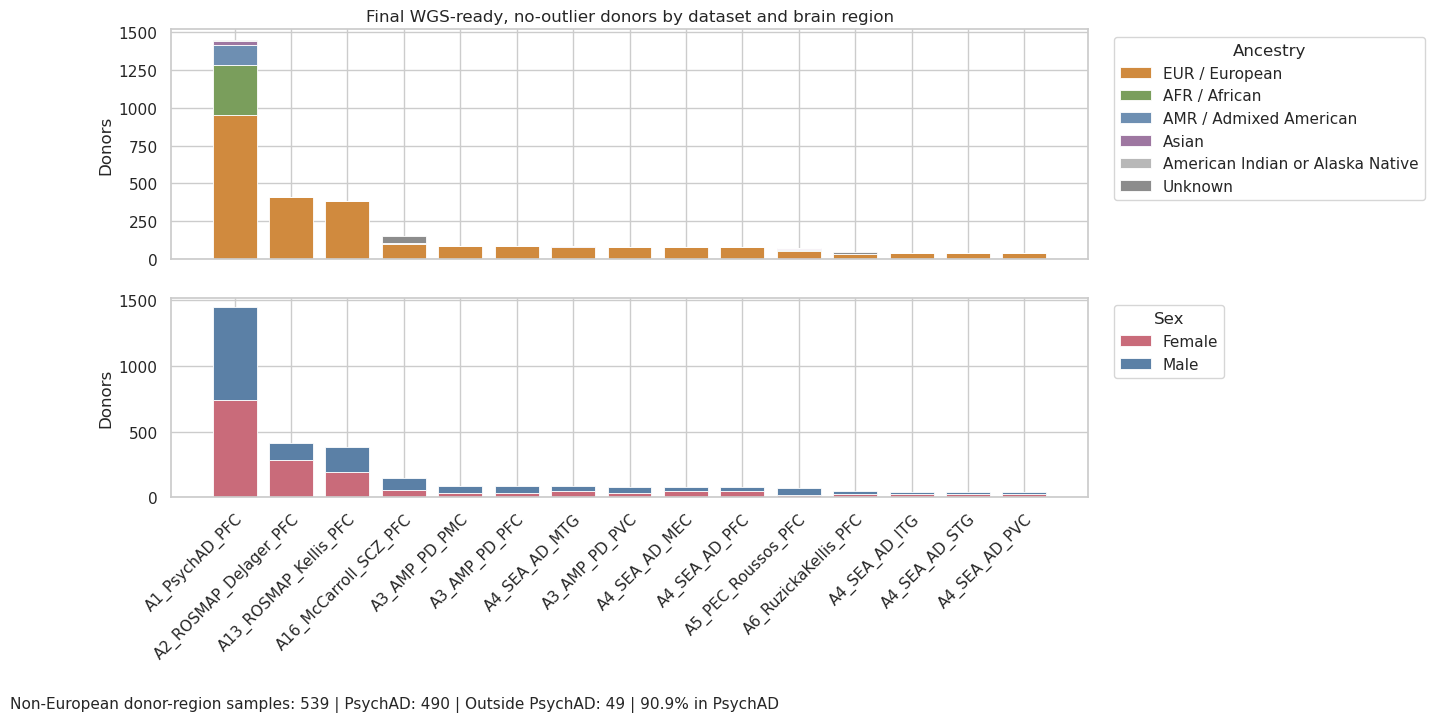

,cohort_region_label,ancestry_clean,n
4,A1_PsychAD_PFC,AFR / African,334
19,A5_PEC_Roussos_PFC,AFR / African,11
0,A13_ROSMAP_Kellis_PFC,AFR / African,2
1,A16_McCarroll_SCZ_PFC,AFR / African,1
7,A3_AMP_PD_PFC,AFR / African,1
9,A3_AMP_PD_PMC,AFR / African,1
11,A3_AMP_PD_PVC,AFR / African,1
5,A1_PsychAD_PFC,AMR / Admixed American,130
20,A5_PEC_Roussos_PFC,AMR / Admixed American,7
10,A3_AMP_PD_PMC,AMR / Admixed American,4


In [35]:
# Final WGS-ready, no-outlier donors by dataset/region: ancestry + sex

import re

def clean_ancestry(x):
    if pd.isna(x) or str(x).strip() == "":
        return "Unknown"

    x0 = str(x).strip()
    x = x0.lower()

    if x in ["eur", "european"] or "white" in x:
        return "EUR / European"
    if x in ["afr", "african"] or "black" in x:
        return "AFR / African"
    if x in ["amr", "american"] or "latino" in x or "hispanic" in x:
        return "AMR / Admixed American"
    if "asian" in x or x in ["eas", "sas", "eas_sas", "east asian", "south asian"]:
        return "Asian"
    if "american indian" in x or "alaska native" in x:
        return "American Indian or Alaska Native"
    if "unknown" in x or "not reported" in x:
        return "Unknown"

    return x0


donor_demo_final["ancestry_clean"] = donor_demo_final["ancestry"].map(clean_ancestry)
donor_demo_final["sex_clean"] = (
    donor_demo_final["sex"]
    .fillna("Unknown")
    .replace("", "Unknown")
)

order = (
    donor_demo_final
    .groupby("cohort_region_label")["donor_id"]
    .nunique()
    .sort_values(ascending=False)
    .index
    .tolist()
)

ancestry_order = [
    "EUR / European",
    "AFR / African",
    "AMR / Admixed American",
    "Asian",
    "American Indian or Alaska Native",
    "Unknown",
]

ancestry_colors = {
    "EUR / European": "#D08A3E",
    "AFR / African": "#7A9E5C",
    "AMR / Admixed American": "#6E8FB2",
    "Asian": "#9E77A1",
    "American Indian or Alaska Native": "#B8B8B8",
    "Unknown": "#8C8C8C",
}

sex_order = ["Female", "Male", "Unknown"]
sex_colors = {
    "Female": "#C96B7A",
    "Male": "#5B80A6",
    "Unknown": "#B8B8B8",
}

ancestry_counts = (
    donor_demo_final
    .groupby(["cohort_region_label", "ancestry_clean"])["donor_id"]
    .nunique()
    .reset_index(name="n")
    .pivot(index="cohort_region_label", columns="ancestry_clean", values="n")
    .fillna(0)
    .reindex(order)
)

for a in ancestry_order:
    if a not in ancestry_counts.columns:
        ancestry_counts[a] = 0
ancestry_counts = ancestry_counts[ancestry_order]

sex_counts = (
    donor_demo_final
    .groupby(["cohort_region_label", "sex_clean"])["donor_id"]
    .nunique()
    .reset_index(name="n")
    .pivot(index="cohort_region_label", columns="sex_clean", values="n")
    .fillna(0)
    .reindex(order)
)

for s in sex_order:
    if s not in sex_counts.columns:
        sex_counts[s] = 0
sex_counts = sex_counts[sex_order]

# Summary numbers for the annotation / slide text.
non_eur_mask = ~donor_demo_final["ancestry_clean"].isin(["EUR / European", "Unknown"])
non_eur = donor_demo_final.loc[non_eur_mask].copy()

psychad_non_eur = non_eur[non_eur["cohort_region_label"].str.contains("PsychAD", na=False)]
outside_psychad_non_eur = non_eur[~non_eur["cohort_region_label"].str.contains("PsychAD", na=False)]

print("Non-European final donor-region samples:", non_eur.shape[0])
print("PsychAD non-European donor-region samples:", psychad_non_eur.shape[0])
print("Outside PsychAD:", outside_psychad_non_eur.shape[0])
print("Percent in PsychAD:", round(100 * psychad_non_eur.shape[0] / non_eur.shape[0], 1))

# Plot
x = np.arange(len(order))

fig, axes = plt.subplots(
    2,
    1,
    figsize=(14, 7.8),
    sharex=True,
    gridspec_kw={"height_ratios": [1.15, 1]},
)

# Top: ancestry
bottom = np.zeros(len(order))
for a in ancestry_order:
    values = ancestry_counts[a].to_numpy()
    if values.sum() == 0:
        continue
    axes[0].bar(
        x,
        values,
        bottom=bottom,
        label=a,
        color=ancestry_colors[a],
        width=0.78,
        edgecolor="white",
        linewidth=0.6,
    )
    bottom += values

axes[0].set_title("Final WGS-ready, no-outlier donors by dataset and brain region")
axes[0].set_ylabel("Donors")
axes[0].legend(title="Ancestry", bbox_to_anchor=(1.02, 1), loc="upper left")

# Bottom: sex
bottom = np.zeros(len(order))
for s in sex_order:
    values = sex_counts[s].to_numpy()
    if values.sum() == 0:
        continue
    axes[1].bar(
        x,
        values,
        bottom=bottom,
        label=s,
        color=sex_colors[s],
        width=0.78,
        edgecolor="white",
        linewidth=0.6,
    )
    bottom += values

axes[1].set_ylabel("Donors")
axes[1].set_xlabel("")
axes[1].legend(title="Sex", bbox_to_anchor=(1.02, 1), loc="upper left")

axes[1].set_xticks(x)
axes[1].set_xticklabels(order, rotation=45, ha="right")
for label in axes[1].get_xticklabels():
    label.set_rotation_mode("anchor")

fig.text(
    0.01,
    0.01,
    f"Non-European donor-region samples: {non_eur.shape[0]:,} | "
    f"PsychAD: {psychad_non_eur.shape[0]:,} | "
    f"Outside PsychAD: {outside_psychad_non_eur.shape[0]:,} | "
    f"{100 * psychad_non_eur.shape[0] / non_eur.shape[0]:.1f}% in PsychAD",
    ha="left",
    fontsize=11,
)

fig.subplots_adjust(bottom=0.28, right=0.78, hspace=0.18)

save_figure(fig, "final_wgs_no_outlier_ancestry_and_sex_by_dataset_region")
plt.show()

# Useful check table: where non-European samples are.
non_eur_table = (
    non_eur
    .groupby(["cohort_region_label", "ancestry_clean"])["donor_id"]
    .nunique()
    .reset_index(name="n")
    .sort_values(["ancestry_clean", "n"], ascending=[True, False])
)

display(non_eur_table)

Saved: outputs/h5ad_metadata_qc/final_wgs_no_outlier_age_distribution_by_dataset_region.png
Saved: outputs/h5ad_metadata_qc/final_wgs_no_outlier_age_distribution_by_dataset_region.pdf


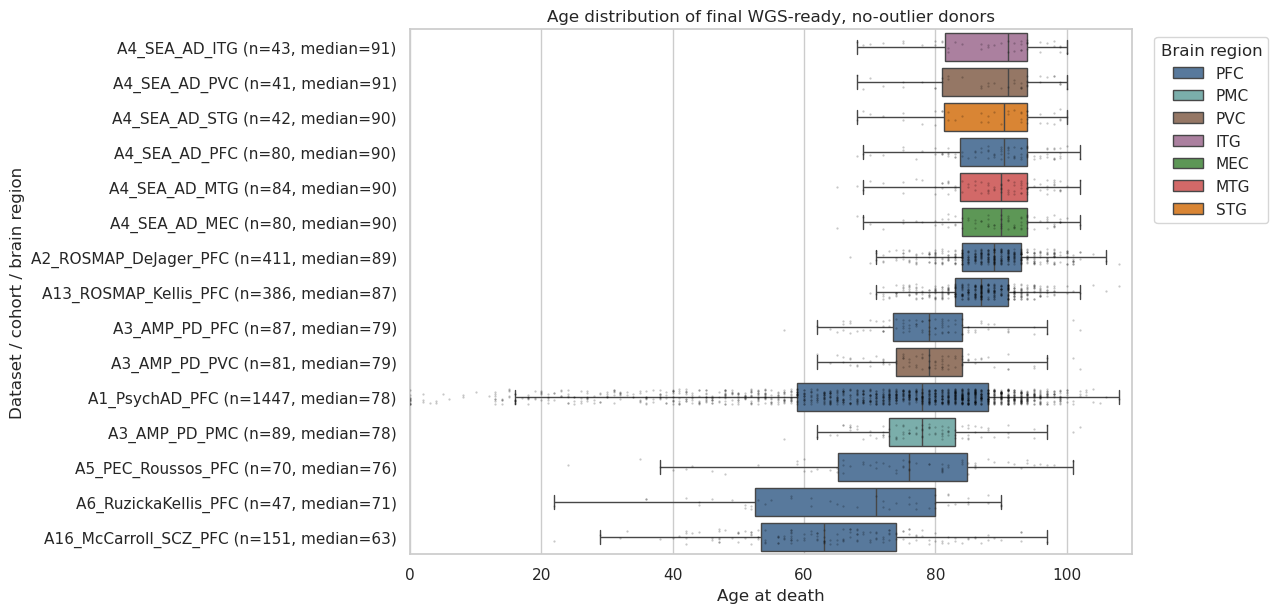

,cohort_region_label,n_donors,median_age,display_label
0,A13_ROSMAP_Kellis_PFC,386,87.0,"A13_ROSMAP_Kellis_PFC (n=386, median=87)"
1,A16_McCarroll_SCZ_PFC,151,63.0,"A16_McCarroll_SCZ_PFC (n=151, median=63)"
2,A1_PsychAD_PFC,1447,78.0,"A1_PsychAD_PFC (n=1447, median=78)"
3,A2_ROSMAP_DeJager_PFC,411,89.0,"A2_ROSMAP_DeJager_PFC (n=411, median=89)"
4,A3_AMP_PD_PFC,87,79.0,"A3_AMP_PD_PFC (n=87, median=79)"
5,A3_AMP_PD_PMC,89,78.0,"A3_AMP_PD_PMC (n=89, median=78)"
6,A3_AMP_PD_PVC,81,79.0,"A3_AMP_PD_PVC (n=81, median=79)"
7,A4_SEA_AD_ITG,43,91.0,"A4_SEA_AD_ITG (n=43, median=91)"
8,A4_SEA_AD_MEC,80,90.0,"A4_SEA_AD_MEC (n=80, median=90)"
9,A4_SEA_AD_MTG,84,90.0,"A4_SEA_AD_MTG (n=84, median=90)"


In [36]:
# Age distribution by dataset/region, final WGS-ready no-outlier donors

def clean_age(x):
    if pd.isna(x):
        return np.nan
    x = str(x).strip()
    m = re.match(r"^(\d+)", x)
    if m:
        return float(m.group(1))
    return np.nan


age_from_primary_gt = (
    primary_gt
    .loc[
        primary_gt["primary_genotype"].notna(),
        ["donor_id", "primary_genotype", "genesis_id", "cohort", "brain_region", "age"],
    ]
    .drop_duplicates(["donor_id", "primary_genotype", "cohort", "brain_region"])
    .copy()
)

age_from_primary_gt["project_short"] = age_from_primary_gt["genesis_id"].map(clean_label_text)

cohort_pretty = {
    "psychad": "PsychAD",
    "rosmap": "ROSMAP_DeJager",
    "amppd": "AMP_PD",
    "seaad": "SEA_AD",
    "pec_cmc": "PEC_Roussos",
    "pec_szbd": "RuzickaKellis",
    "rosmap_kellis": "ROSMAP_Kellis",
    "pec_mccarroll": "McCarroll_SCZ",
}

age_from_primary_gt["cohort_pretty"] = (
    age_from_primary_gt["cohort"]
    .map(cohort_pretty)
    .fillna(age_from_primary_gt["cohort"])
)

age_from_primary_gt["cohort_region_label"] = (
    age_from_primary_gt["project_short"] + "_" +
    age_from_primary_gt["cohort_pretty"].map(clean_label_text) + "_" +
    age_from_primary_gt["brain_region"].fillna("PFC")
)

age_from_primary_gt["age_clean"] = age_from_primary_gt["age"].map(clean_age)

age_final = (
    cell_metadata_wgs
    .drop_duplicates(["cohort_region_label", "donor_id", "primary_genotype"])
    [["cohort_region_label", "donor_id", "primary_genotype"]]
    .merge(
        age_from_primary_gt[["cohort_region_label", "donor_id", "primary_genotype", "age_clean"]],
        on=["cohort_region_label", "donor_id", "primary_genotype"],
        how="left",
    )
)

age_stats = (
    age_final
    .groupby("cohort_region_label", dropna=False)
    .agg(
        n_donors=("donor_id", "nunique"),
        median_age=("age_clean", "median"),
    )
    .reset_index()
)

age_stats["display_label"] = age_stats.apply(
    lambda r: f"{r['cohort_region_label']} (n={int(r['n_donors'])}, median={r['median_age']:.0f})",
    axis=1,
)

label_map = dict(zip(age_stats["cohort_region_label"], age_stats["display_label"]))
age_final["display_label"] = age_final["cohort_region_label"].map(label_map)

age_order = (
    age_stats
    .sort_values("median_age", ascending=False)["display_label"]
    .tolist()
)

age_final["brain_region"] = age_final["cohort_region_label"].str.split("_").str[-1]

fig, ax = plt.subplots(figsize=(13, max(5, 0.42 * len(age_order))))

sns.boxplot(
    data=age_final,
    y="display_label",
    x="age_clean",
    hue="brain_region",
    order=age_order,
    palette=region_palette,
    dodge=False,
    showfliers=False,
    ax=ax,
)

sns.stripplot(
    data=age_final,
    y="display_label",
    x="age_clean",
    order=age_order,
    color="black",
    alpha=0.22,
    size=1.6,
    jitter=0.22,
    ax=ax,
)

ax.set_title("Age distribution of final WGS-ready, no-outlier donors")
ax.set_xlabel("Age at death")
ax.set_ylabel("Dataset / cohort / brain region")
ax.set_xlim(0, 110)
ax.legend(title="Brain region", bbox_to_anchor=(1.02, 1), loc="upper left")

plt.tight_layout()
save_figure(fig, "final_wgs_no_outlier_age_distribution_by_dataset_region")
plt.show()

age_stats

In [45]:
total_regions = region_summary["brain_region"].nunique()
total_donors = region_summary["n_donors"].sum()
total_nuclei = region_summary["n_nuclei"].sum()

print(f"Total brain regions: {total_regions}")
print(f"Total WGS-ready donors: {total_donors:,}")
print(f"Total WGS-ready nuclei: {total_nuclei:,}")

Total brain regions: 7
Total WGS-ready donors: 2,921
Total WGS-ready nuclei: 16,880,935


In [46]:
unique_donors = cell_metadata_wgs["donor_id"].nunique()
unique_donors

2471

In [47]:
unique_donors_by_region = (
    cell_metadata_wgs
    .groupby("brain_region")["donor_id"]
    .nunique()
    .reset_index(name="unique_donors")
    .sort_values("unique_donors", ascending=False)
)

unique_donors_by_region

,brain_region,unique_donors
3,PFC,2460
5,PVC,122
4,PMC,89
2,MTG,84
1,MEC,81
0,ITG,43
6,STG,42


Panel A total donor-region samples: 3139
Expected final donor-region samples: 3139


/tmp/ipykernel_3572400/4143832358.py:218: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(
/tmp/ipykernel_3572400/4143832358.py:234: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(
/tmp/ipykernel_3572400/4143832358.py:251: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(
/tmp/ipykernel_3572400/4143832358.py:316: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(


Saved: outputs/h5ad_metadata_qc/manuscript_region_summary_6panel_final_wgs_no_outlier.png
Saved: outputs/h5ad_metadata_qc/manuscript_region_summary_6panel_final_wgs_no_outlier.pdf


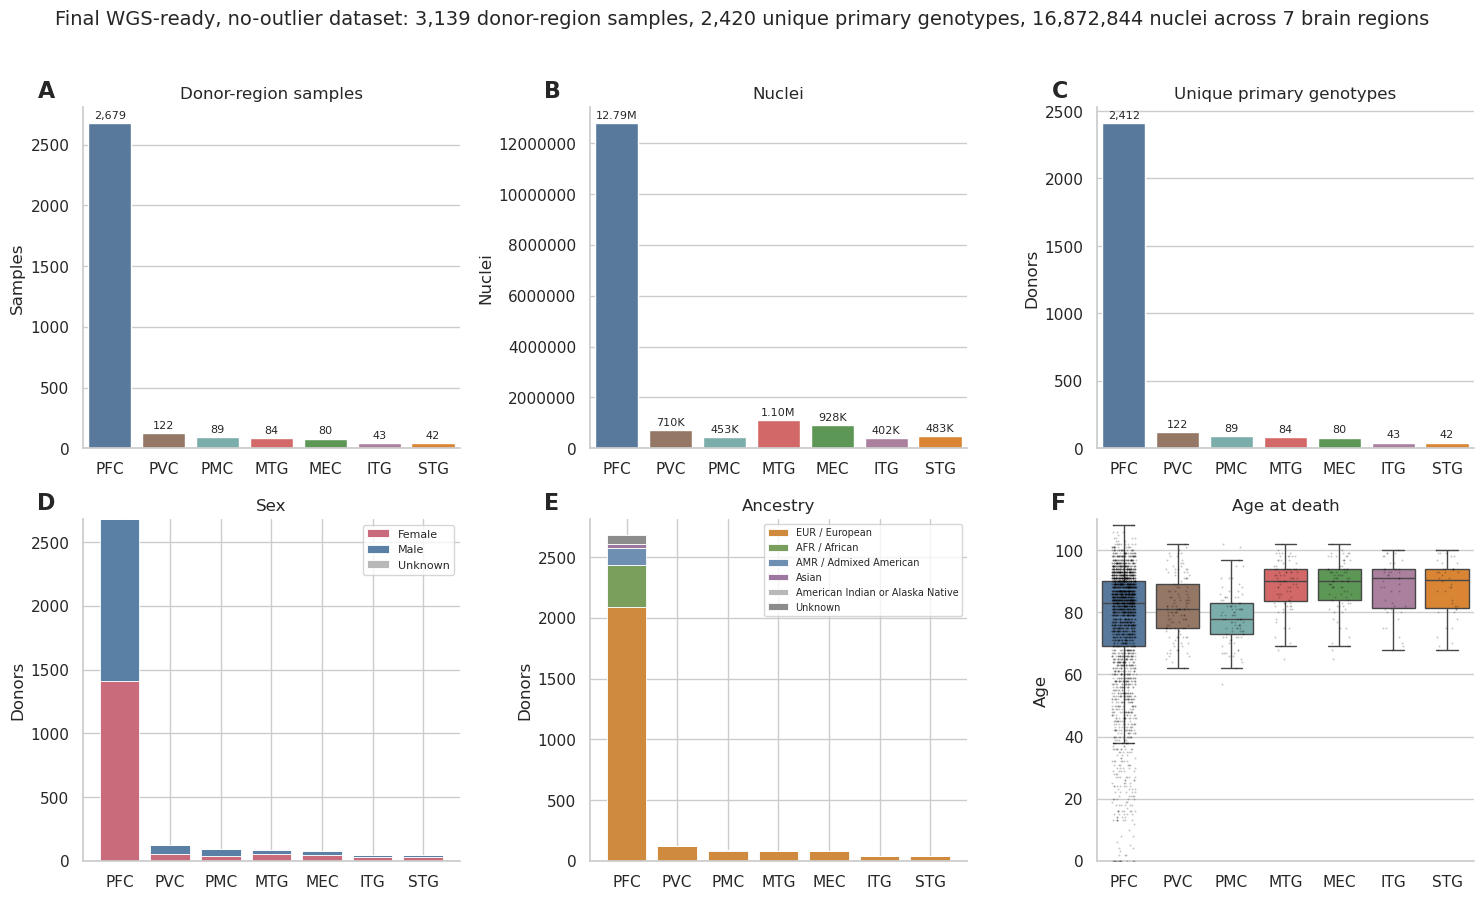

,brain_region,n_donor_region_samples,n_primary_genotypes,n_nuclei
3,PFC,2679,2412,12793950
5,PVC,122,122,710483
4,PMC,89,89,453281
2,MTG,84,84,1102490
1,MEC,80,80,927923
0,ITG,43,43,402054
6,STG,42,42,482663


In [44]:
# Manuscript-style 6-panel region summary figure
# Final WGS-ready, no-outlier donor-region samples

import re
from matplotlib.patches import Patch

def clean_age(x):
    if pd.isna(x):
        return np.nan
    x = str(x).strip()
    m = re.match(r"^(\d+)", x)
    if m:
        return float(m.group(1))
    return np.nan

def clean_ancestry(x):
    if pd.isna(x) or str(x).strip() == "":
        return "Unknown"
    x0 = str(x).strip()
    x = x0.lower()

    if x in ["eur", "european"] or "white" in x:
        return "EUR / European"
    if x in ["afr", "african"] or "black" in x:
        return "AFR / African"
    if x in ["amr", "american"] or "latino" in x or "hispanic" in x:
        return "AMR / Admixed American"
    if "asian" in x or x in ["eas", "sas", "eas_sas", "east asian", "south asian"]:
        return "Asian"
    if "american indian" in x or "alaska native" in x:
        return "American Indian or Alaska Native"
    if "unknown" in x or "not reported" in x:
        return "Unknown"
    return x0

region_order = ["PFC", "PVC", "PMC", "MTG", "MEC", "ITG", "STG"]

region_palette = {
    "PFC": "#4C78A8",
    "PMC": "#72B7B2",
    "PVC": "#9D755D",
    "MTG": "#E45756",
    "MEC": "#54A24B",
    "ITG": "#B279A2",
    "STG": "#F58518",
}

sex_order = ["Female", "Male", "Unknown"]
sex_colors = {
    "Female": "#C96B7A",
    "Male": "#5B80A6",
    "Unknown": "#B8B8B8",
}

ancestry_order = [
    "EUR / European",
    "AFR / African",
    "AMR / Admixed American",
    "Asian",
    "American Indian or Alaska Native",
    "Unknown",
]
ancestry_colors = {
    "EUR / European": "#D08A3E",
    "AFR / African": "#7A9E5C",
    "AMR / Admixed American": "#6E8FB2",
    "Asian": "#9E77A1",
    "American Indian or Alaska Native": "#B8B8B8",
    "Unknown": "#8C8C8C",
}

# Add donor-level demographic columns from primary_gt.
demo_cols = ["donor_id", "primary_genotype", "genesis_id", "cohort", "brain_region", "sex", "ancestry", "age"]

demo_from_primary_gt = (
    primary_gt
    .loc[primary_gt["primary_genotype"].notna(), [c for c in demo_cols if c in primary_gt.columns]]
    .drop_duplicates(["donor_id", "primary_genotype", "cohort", "brain_region"])
    .copy()
)

demo_from_primary_gt["project_short"] = demo_from_primary_gt["genesis_id"].map(clean_label_text)

cohort_pretty = {
    "psychad": "PsychAD",
    "rosmap": "ROSMAP_DeJager",
    "amppd": "AMP_PD",
    "seaad": "SEA_AD",
    "pec_cmc": "PEC_Roussos",
    "pec_szbd": "RuzickaKellis",
    "rosmap_kellis": "ROSMAP_Kellis",
    "pec_mccarroll": "McCarroll_SCZ",
}

demo_from_primary_gt["cohort_pretty"] = (
    demo_from_primary_gt["cohort"]
    .map(cohort_pretty)
    .fillna(demo_from_primary_gt["cohort"])
)

demo_from_primary_gt["cohort_region_label"] = (
    demo_from_primary_gt["project_short"] + "_" +
    demo_from_primary_gt["cohort_pretty"].map(clean_label_text) + "_" +
    demo_from_primary_gt["brain_region"].fillna("PFC")
)

demo_from_primary_gt["age_clean"] = demo_from_primary_gt["age"].map(clean_age)
demo_from_primary_gt["ancestry_clean"] = demo_from_primary_gt["ancestry"].map(clean_ancestry)
demo_from_primary_gt["sex_clean"] = (
    demo_from_primary_gt["sex"]
    .fillna("Unknown")
    .replace("", "Unknown")
)

donor_region_demo = (
    cell_metadata_wgs
    .drop_duplicates(["cohort_region_label", "donor_id", "primary_genotype", "brain_region"])
    [["cohort_region_label", "donor_id", "primary_genotype", "brain_region"]]
    .merge(
        demo_from_primary_gt[
            ["cohort_region_label", "donor_id", "primary_genotype", "sex_clean", "ancestry_clean", "age_clean"]
        ],
        on=["cohort_region_label", "donor_id", "primary_genotype"],
        how="left",
    )
)


# Correct donor-region sample table.
donor_region_demo_unique = (
    donor_region_demo
    .drop_duplicates(["cohort_region_label", "donor_id", "primary_genotype"])
    .copy()
)

region_summary_final = (
    donor_region_demo_unique
    .groupby("brain_region", dropna=False)
    .agg(
        n_donor_region_samples=("donor_id", "size"),
        n_primary_genotypes=("primary_genotype", "nunique"),
    )
    .reset_index()
)

nuclei_by_region = (
    cell_metadata_wgs
    .groupby("brain_region", dropna=False)
    .agg(n_nuclei=("donor_id", "size"))
    .reset_index()
)

region_summary_final = region_summary_final.merge(
    nuclei_by_region,
    on="brain_region",
    how="left",
)

region_summary_final["brain_region"] = pd.Categorical(
    region_summary_final["brain_region"],
    categories=region_order,
    ordered=True,
)
region_summary_final = region_summary_final.sort_values("brain_region")

# Correct stacked bars: donor-region samples, not collapsed donor IDs.
sex_counts = (
    donor_region_demo_unique
    .groupby(["brain_region", "sex_clean"], dropna=False)
    .size()
    .reset_index(name="n")
    .pivot(index="brain_region", columns="sex_clean", values="n")
    .fillna(0)
    .reindex(region_order)
)

for s in sex_order:
    if s not in sex_counts.columns:
        sex_counts[s] = 0
sex_counts = sex_counts[sex_order]

ancestry_counts = (
    donor_region_demo_unique
    .groupby(["brain_region", "ancestry_clean"], dropna=False)
    .size()
    .reset_index(name="n")
    .pivot(index="brain_region", columns="ancestry_clean", values="n")
    .fillna(0)
    .reindex(region_order)
)

for a in ancestry_order:
    if a not in ancestry_counts.columns:
        ancestry_counts[a] = 0
ancestry_counts = ancestry_counts[ancestry_order]

# Sanity check
print("Panel A total donor-region samples:", int(region_summary_final["n_donor_region_samples"].sum()))
print("Expected final donor-region samples:", int(wgs_table["final_after_outlier_qc"].sum()))

# Plot.
fig, axes = plt.subplots(2, 3, figsize=(15, 8.8))
axes = axes.flatten()

panel_labels = ["A", "B", "C", "D", "E", "F"]

def panel_label(ax, label):
    ax.text(
        -0.12, 1.08, label,
        transform=ax.transAxes,
        fontsize=16,
        fontweight="bold",
        va="top",
        ha="left",
    )

# A: donor-region samples
sns.barplot(
    data=region_summary_final,
    x="brain_region",
    y="n_donor_region_samples",
    order=region_order,
    palette=region_palette,
    ax=axes[0],
)
axes[0].set_title("Donor-region samples")
axes[0].set_xlabel("")
axes[0].set_ylabel("Samples")
for c in axes[0].containers:
    axes[0].bar_label(c, labels=[comma_int(v.get_height()) for v in c], padding=2, fontsize=8)
panel_label(axes[0], "A")

# B: nuclei
sns.barplot(
    data=region_summary_final,
    x="brain_region",
    y="n_nuclei",
    order=region_order,
    palette=region_palette,
    ax=axes[1],
)
axes[1].set_title("Nuclei")
axes[1].set_xlabel("")
axes[1].set_ylabel("Nuclei")
axes[1].ticklabel_format(axis="y", style="plain")
for c in axes[1].containers:
    axes[1].bar_label(c, labels=[compact_count(v.get_height()) for v in c], padding=2, fontsize=8)
panel_label(axes[1], "B")

# C: unique donors / primary genotypes
sns.barplot(
    data=region_summary_final,
    x="brain_region",
    y="n_primary_genotypes",
    order=region_order,
    palette=region_palette,
    ax=axes[2],
)
axes[2].set_title("Unique primary genotypes")
axes[2].set_xlabel("")
axes[2].set_ylabel("Donors")
for c in axes[2].containers:
    axes[2].bar_label(c, labels=[comma_int(v.get_height()) for v in c], padding=2, fontsize=8)
panel_label(axes[2], "C")

# D: sex stacked bars
x = np.arange(len(region_order))
bottom = np.zeros(len(region_order))
for s in sex_order:
    vals = sex_counts[s].to_numpy()
    axes[3].bar(
        x,
        vals,
        bottom=bottom,
        color=sex_colors[s],
        label=s,
        width=0.78,
        edgecolor="white",
        linewidth=0.6,
    )
    bottom += vals

axes[3].set_title("Sex")
axes[3].set_xticks(x)
axes[3].set_xticklabels(region_order)
axes[3].set_ylabel("Donors")
axes[3].legend(title="", frameon=True, fontsize=8)
panel_label(axes[3], "D")

# E: ancestry stacked bars
bottom = np.zeros(len(region_order))
for a in ancestry_order:
    vals = ancestry_counts[a].to_numpy()
    if vals.sum() == 0:
        continue
    axes[4].bar(
        x,
        vals,
        bottom=bottom,
        color=ancestry_colors[a],
        label=a,
        width=0.78,
        edgecolor="white",
        linewidth=0.6,
    )
    bottom += vals

axes[4].set_title("Ancestry")
axes[4].set_xticks(x)
axes[4].set_xticklabels(region_order)
axes[4].set_ylabel("Donors")
axes[4].legend(title="", frameon=True, fontsize=7, loc="upper right")
panel_label(axes[4], "E")

# F: age distribution
sns.boxplot(
    data=donor_region_demo,
    x="brain_region",
    y="age_clean",
    order=region_order,
    palette=region_palette,
    showfliers=False,
    ax=axes[5],
)
sns.stripplot(
    data=donor_region_demo,
    x="brain_region",
    y="age_clean",
    order=region_order,
    color="black",
    alpha=0.22,
    size=1.4,
    jitter=0.22,
    ax=axes[5],
)
axes[5].set_title("Age at death")
axes[5].set_xlabel("")
axes[5].set_ylabel("Age")
axes[5].set_ylim(0, 110)
panel_label(axes[5], "F")

for ax in axes:
    ax.tick_params(axis="x", rotation=0)
    sns.despine(ax=ax)

total_samples = int(region_summary_final["n_donor_region_samples"].sum())
total_nuclei = int(region_summary_final["n_nuclei"].sum())
total_unique = int(donor_region_demo_unique["primary_genotype"].nunique())
total_regions = region_summary_final["brain_region"].nunique()

fig.suptitle(
    f"Final WGS-ready, no-outlier dataset: {total_samples:,} donor-region samples, "
    f"{total_unique:,} unique primary genotypes, {total_nuclei:,} nuclei across {total_regions} brain regions",
    fontsize=14,
    y=1.02,
)

plt.tight_layout()
save_figure(fig, "manuscript_region_summary_6panel_final_wgs_no_outlier")
plt.show()

region_summary_final

non_eur = check_ancestry[
    ~check_ancestry["ancestry_clean"].isin(["EUR / European", "Unknown"])
].copy()

non_eur["is_psychad"] = non_eur["cohort_region"].str.contains("PsychAD", case=False, na=False)

display(non_eur)

print("All non-European ancestry only in PsychAD?")
print(non_eur["is_psychad"].all())

In [43]:
n_donor_region_samples=("donor_id", "nunique")
# Correct donor-region sample table.
donor_region_demo_unique = (
    donor_region_demo
    .drop_duplicates(["cohort_region_label", "donor_id", "primary_genotype"])
    .copy()
)

region_summary_final = (
    donor_region_demo_unique
    .groupby("brain_region", dropna=False)
    .agg(
        n_donor_region_samples=("donor_id", "size"),
        n_primary_genotypes=("primary_genotype", "nunique"),
    )
    .reset_index()
)

nuclei_by_region = (
    cell_metadata_wgs
    .groupby("brain_region", dropna=False)
    .agg(n_nuclei=("donor_id", "size"))
    .reset_index()
)

region_summary_final = region_summary_final.merge(
    nuclei_by_region,
    on="brain_region",
    how="left",
)

region_summary_final["brain_region"] = pd.Categorical(
    region_summary_final["brain_region"],
    categories=region_order,
    ordered=True,
)
region_summary_final = region_summary_final.sort_values("brain_region")

# Correct stacked bars: donor-region samples, not collapsed donor IDs.
sex_counts = (
    donor_region_demo_unique
    .groupby(["brain_region", "sex_clean"], dropna=False)
    .size()
    .reset_index(name="n")
    .pivot(index="brain_region", columns="sex_clean", values="n")
    .fillna(0)
    .reindex(region_order)
)

for s in sex_order:
    if s not in sex_counts.columns:
        sex_counts[s] = 0
sex_counts = sex_counts[sex_order]

ancestry_counts = (
    donor_region_demo_unique
    .groupby(["brain_region", "ancestry_clean"], dropna=False)
    .size()
    .reset_index(name="n")
    .pivot(index="brain_region", columns="ancestry_clean", values="n")
    .fillna(0)
    .reindex(region_order)
)

for a in ancestry_order:
    if a not in ancestry_counts.columns:
        ancestry_counts[a] = 0
ancestry_counts = ancestry_counts[ancestry_order]


# Sanity check
print("Panel A total donor-region samples:", int(region_summary_final["n_donor_region_samples"].sum()))
print("Expected final donor-region samples:", int(wgs_table["final_after_outlier_qc"].sum()))

/tmp/ipykernel_3572400/3224889024.py:10: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  donor_region_demo_unique


Panel A total donor-region samples: 3139
Expected final donor-region samples: 3139


/tmp/ipykernel_3572400/3224889024.py:41: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  donor_region_demo_unique
/tmp/ipykernel_3572400/3224889024.py:56: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  donor_region_demo_unique


/tmp/ipykernel_3572400/3685496737.py:77: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(
/tmp/ipykernel_3572400/3685496737.py:93: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(
/tmp/ipykernel_3572400/3685496737.py:110: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(
/tmp/ipykernel_3572400/3685496737.py:125: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


Saved: outputs/h5ad_metadata_qc/manuscript_overall_summary_6panel_final_wgs_no_outlier.png
Saved: outputs/h5ad_metadata_qc/manuscript_overall_summary_6panel_final_wgs_no_outlier.pdf


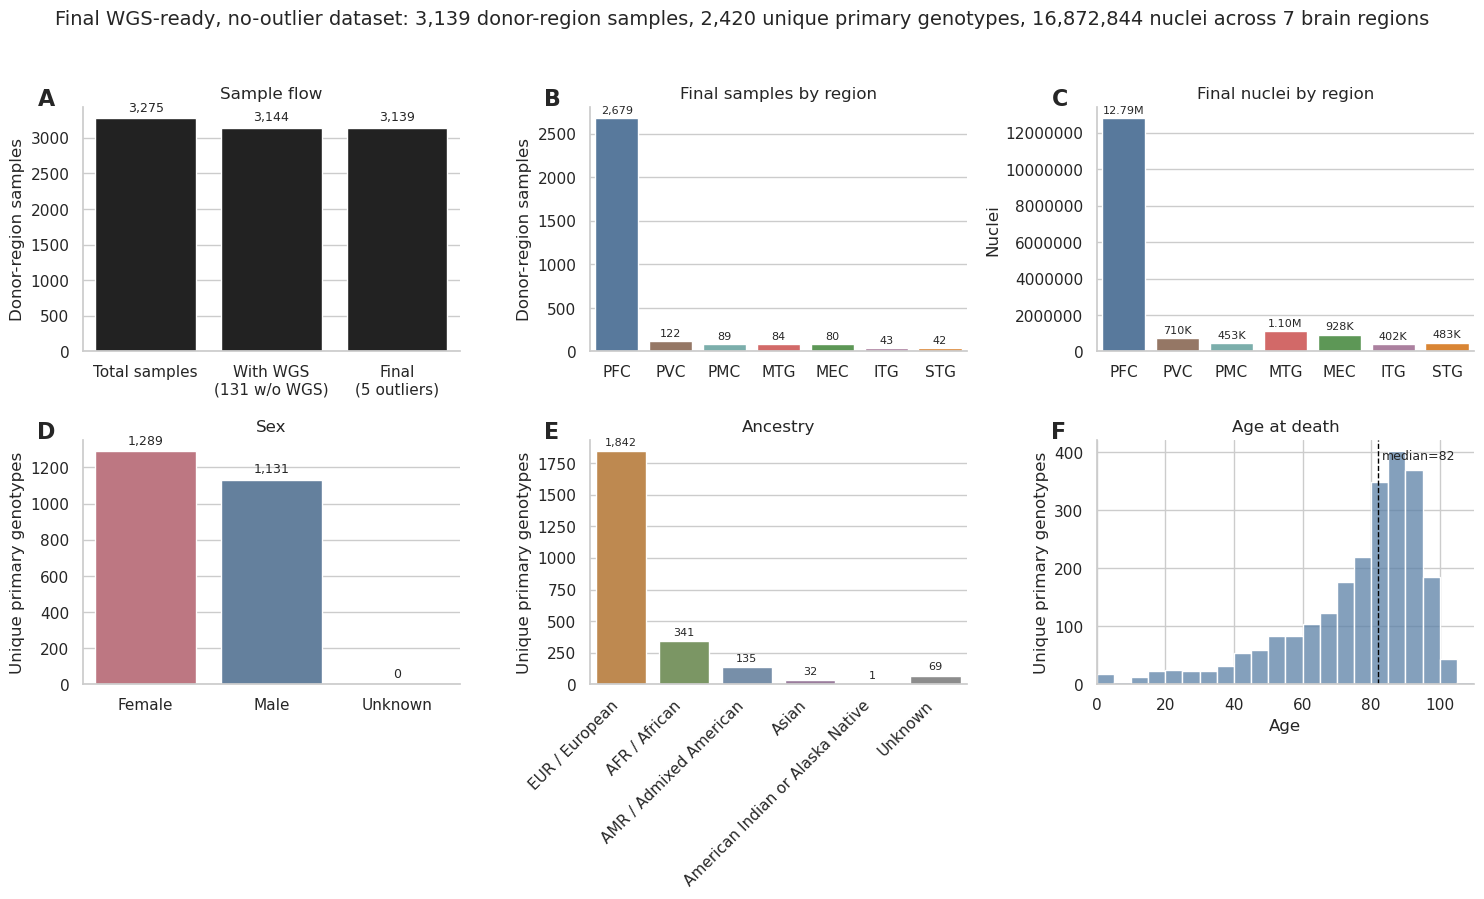

In [45]:
# Overall 6-panel summary across all final WGS-ready, no-outlier samples

# Unique final donors/genotypes for demographic panels.
final_unique_demo = (
    donor_region_demo_unique
    .sort_values(["primary_genotype", "cohort_region_label"])
    .drop_duplicates("primary_genotype")
    .copy()
)

total_samples = int(wgs_table["n_h5ad_donors"].sum())
with_wgs = int(wgs_table["n_donors_with_primary_genotype"].sum())
final_samples = int(wgs_table["final_after_outlier_qc"].sum())
no_wgs = int(wgs_table["without_wgs"].sum())
outliers = int(wgs_table["outliers_removed"].sum())

total_final_unique = int(final_unique_demo["primary_genotype"].nunique())
total_final_nuclei = int(cell_metadata_wgs.shape[0])
total_regions = int(region_summary_final["brain_region"].nunique())

flow_df = pd.DataFrame({
    "stage": [
        "Total samples",
        f"With WGS\n({no_wgs:,} w/o WGS)",
        f"Final\n({outliers:,} outliers)",
    ],
    "n": [total_samples, with_wgs, final_samples],
})

sex_counts_all = (
    final_unique_demo
    .groupby("sex_clean", dropna=False)["primary_genotype"]
    .nunique()
    .reindex(sex_order)
    .fillna(0)
    .reset_index(name="n")
)

ancestry_counts_all = (
    final_unique_demo
    .groupby("ancestry_clean", dropna=False)["primary_genotype"]
    .nunique()
    .reindex(ancestry_order)
    .fillna(0)
    .reset_index(name="n")
)

fig, axes = plt.subplots(2, 3, figsize=(15, 8.8))
axes = axes.flatten()

def panel_label(ax, label):
    ax.text(
        -0.12, 1.08, label,
        transform=ax.transAxes,
        fontsize=16,
        fontweight="bold",
        va="top",
        ha="left",
    )

# A. Sample flow
sns.barplot(
    data=flow_df,
    x="stage",
    y="n",
    color="#222222",
    ax=axes[0],
)
axes[0].set_title("Sample flow")
axes[0].set_xlabel("")
axes[0].set_ylabel("Donor-region samples")
for c in axes[0].containers:
    axes[0].bar_label(c, labels=[comma_int(v.get_height()) for v in c], padding=3, fontsize=9)
panel_label(axes[0], "A")

# B. Donor-region samples by region
sns.barplot(
    data=region_summary_final,
    x="brain_region",
    y="n_donor_region_samples",
    order=region_order,
    palette=region_palette,
    ax=axes[1],
)
axes[1].set_title("Final samples by region")
axes[1].set_xlabel("")
axes[1].set_ylabel("Donor-region samples")
for c in axes[1].containers:
    axes[1].bar_label(c, labels=[comma_int(v.get_height()) for v in c], padding=2, fontsize=8)
panel_label(axes[1], "B")

# C. Nuclei by region
sns.barplot(
    data=region_summary_final,
    x="brain_region",
    y="n_nuclei",
    order=region_order,
    palette=region_palette,
    ax=axes[2],
)
axes[2].set_title("Final nuclei by region")
axes[2].set_xlabel("")
axes[2].set_ylabel("Nuclei")
axes[2].ticklabel_format(axis="y", style="plain")
for c in axes[2].containers:
    axes[2].bar_label(c, labels=[compact_count(v.get_height()) for v in c], padding=2, fontsize=8)
panel_label(axes[2], "C")

# D. Sex, unique primary genotypes
sns.barplot(
    data=sex_counts_all,
    x="sex_clean",
    y="n",
    palette=sex_colors,
    ax=axes[3],
)
axes[3].set_title("Sex")
axes[3].set_xlabel("")
axes[3].set_ylabel("Unique primary genotypes")
for c in axes[3].containers:
    axes[3].bar_label(c, labels=[comma_int(v.get_height()) for v in c], padding=3, fontsize=9)
panel_label(axes[3], "D")

# E. Ancestry, unique primary genotypes
sns.barplot(
    data=ancestry_counts_all,
    x="ancestry_clean",
    y="n",
    palette=ancestry_colors,
    ax=axes[4],
)
axes[4].set_title("Ancestry")
axes[4].set_xlabel("")
axes[4].set_ylabel("Unique primary genotypes")
axes[4].tick_params(axis="x", rotation=45)
for label in axes[4].get_xticklabels():
    label.set_ha("right")
for c in axes[4].containers:
    axes[4].bar_label(c, labels=[comma_int(v.get_height()) for v in c], padding=3, fontsize=8)
panel_label(axes[4], "E")

# F. Age, unique primary genotypes
sns.histplot(
    data=final_unique_demo,
    x="age_clean",
    bins=np.arange(0, 111, 5),
    color="#5B80A6",
    edgecolor="white",
    ax=axes[5],
)
median_age = final_unique_demo["age_clean"].median()
axes[5].axvline(median_age, color="black", linestyle="--", linewidth=1)
axes[5].text(
    median_age + 1,
    axes[5].get_ylim()[1] * 0.92,
    f"median={median_age:.0f}",
    fontsize=9,
)
axes[5].set_title("Age at death")
axes[5].set_xlabel("Age")
axes[5].set_ylabel("Unique primary genotypes")
axes[5].set_xlim(0, 110)
panel_label(axes[5], "F")

for ax in axes:
    sns.despine(ax=ax)

fig.suptitle(
    f"Final WGS-ready, no-outlier dataset: {final_samples:,} donor-region samples, "
    f"{total_final_unique:,} unique primary genotypes, "
    f"{total_final_nuclei:,} nuclei across {total_regions} brain regions",
    fontsize=14,
    y=1.02,
)

plt.tight_layout()
save_figure(fig, "manuscript_overall_summary_6panel_final_wgs_no_outlier")
plt.show()

/tmp/ipykernel_3572400/3899400551.py:20: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  donor_region_nuclei
/tmp/ipykernel_3572400/3899400551.py:42: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(


Saved: outputs/h5ad_metadata_qc/final_wgs_no_outlier_nuclei_per_sample_by_region_boxplot_clean.png
Saved: outputs/h5ad_metadata_qc/final_wgs_no_outlier_nuclei_per_sample_by_region_boxplot_clean.pdf


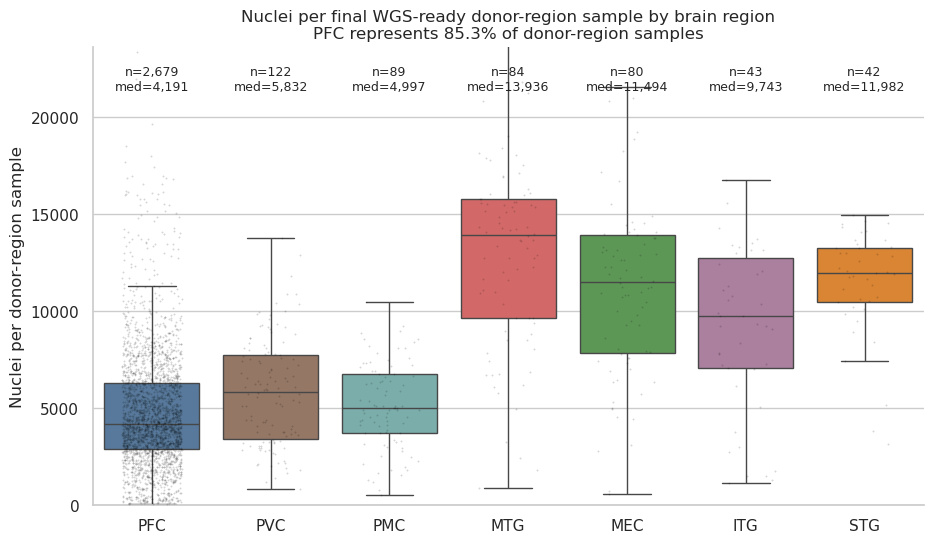

,brain_region,n_samples,median_nuclei
0,PFC,2679,4191.0
1,PVC,122,5832.0
2,PMC,89,4997.0
3,MTG,84,13936.0
4,MEC,80,11494.5
5,ITG,43,9743.0
6,STG,42,11981.5


In [48]:
# Clean box plot: nuclei per donor-region sample by brain region
# n and median are shown above each box, not in x-axis labels.

region_order = ["PFC", "PVC", "PMC", "MTG", "MEC", "ITG", "STG"]

donor_region_nuclei = (
    cell_metadata_wgs
    .groupby(["cohort_region_label", "brain_region", "donor_id", "primary_genotype"], dropna=False)
    .size()
    .reset_index(name="nuclei_per_donor_region")
)

donor_region_nuclei["brain_region"] = pd.Categorical(
    donor_region_nuclei["brain_region"],
    categories=region_order,
    ordered=True,
)

region_stats = (
    donor_region_nuclei
    .groupby("brain_region", dropna=False)
    .agg(
        n_samples=("nuclei_per_donor_region", "size"),
        median_nuclei=("nuclei_per_donor_region", "median"),
    )
    .reset_index()
)

region_stats["brain_region"] = pd.Categorical(
    region_stats["brain_region"],
    categories=region_order,
    ordered=True,
)
region_stats = region_stats.sort_values("brain_region")

total_samples = region_stats["n_samples"].sum()
pfc_samples = int(region_stats.loc[region_stats["brain_region"].astype(str).eq("PFC"), "n_samples"].iloc[0])
pfc_sample_pct = 100 * pfc_samples / total_samples

fig, ax = plt.subplots(figsize=(9.5, 5.6))

sns.boxplot(
    data=donor_region_nuclei,
    x="brain_region",
    y="nuclei_per_donor_region",
    order=region_order,
    palette=region_palette,
    showfliers=False,
    ax=ax,
)

sns.stripplot(
    data=donor_region_nuclei,
    x="brain_region",
    y="nuclei_per_donor_region",
    order=region_order,
    color="black",
    alpha=0.16,
    size=1.4,
    jitter=0.25,
    ax=ax,
)

y_top = donor_region_nuclei["nuclei_per_donor_region"].quantile(0.995)
ax.set_ylim(0, y_top * 1.18)

for i, region in enumerate(region_order):
    row = region_stats[region_stats["brain_region"].astype(str).eq(region)]
    if row.empty:
        continue

    n = int(row["n_samples"].iloc[0])
    med = int(round(row["median_nuclei"].iloc[0]))

    ax.text(
        i,
        y_top * 1.06,
        f"n={n:,}\nmed={med:,}",
        ha="center",
        va="bottom",
        fontsize=9,
    )

ax.set_title(
    f"Nuclei per final WGS-ready donor-region sample by brain region\n"
    f"PFC represents {pfc_sample_pct:.1f}% of donor-region samples"
)
ax.set_xlabel("")
ax.set_ylabel("Nuclei per donor-region sample")
ax.tick_params(axis="x", rotation=0)
sns.despine(ax=ax)

plt.tight_layout()
save_figure(fig, "final_wgs_no_outlier_nuclei_per_sample_by_region_boxplot_clean")
plt.show()

region_stats

In [72]:
568-519

49

In [49]:
final_unique_demo = (
    donor_region_demo_unique
    .sort_values(["primary_genotype", "cohort_region_label"])
    .drop_duplicates("primary_genotype")
    .copy()
)

# Sex counts and percentages
sex_summary = (
    final_unique_demo
    .groupby("sex_clean", dropna=False)["primary_genotype"]
    .nunique()
    .reset_index(name="n")
)
sex_summary["percent"] = 100 * sex_summary["n"] / sex_summary["n"].sum()
sex_summary["percent"] = sex_summary["percent"].round(1)

display(sex_summary)

# Caucasian / European counts and percentages
ancestry_summary = (
    final_unique_demo
    .groupby("ancestry_clean", dropna=False)["primary_genotype"]
    .nunique()
    .reset_index(name="n")
)
ancestry_summary["percent"] = 100 * ancestry_summary["n"] / ancestry_summary["n"].sum()
ancestry_summary["percent"] = ancestry_summary["percent"].round(1)

display(ancestry_summary)

# Quick print
n_total = final_unique_demo["primary_genotype"].nunique()

n_eur = final_unique_demo.loc[
    final_unique_demo["ancestry_clean"].eq("EUR / European"),
    "primary_genotype"
].nunique()

n_female = final_unique_demo.loc[
    final_unique_demo["sex_clean"].eq("Female"),
    "primary_genotype"
].nunique()

n_male = final_unique_demo.loc[
    final_unique_demo["sex_clean"].eq("Male"),
    "primary_genotype"
].nunique()

print(f"Total unique primary genotypes: {n_total:,}")
print(f"European/Caucasian: {n_eur:,} ({100*n_eur/n_total:.1f}%)")
print(f"Female: {n_female:,} ({100*n_female/n_total:.1f}%)")
print(f"Male: {n_male:,} ({100*n_male/n_total:.1f}%)")

,sex_clean,n,percent
0,Female,1289,53.3
1,Male,1131,46.7


,ancestry_clean,n,percent
0,AFR / African,341,14.1
1,AMR / Admixed American,135,5.6
2,American Indian or Alaska Native,1,0.0
3,Asian,32,1.3
4,EUR / European,1842,76.1
5,Unknown,69,2.9


Total unique primary genotypes: 2,420
European/Caucasian: 1,842 (76.1%)
Female: 1,289 (53.3%)
Male: 1,131 (46.7%)


In [50]:
# Non-European donor-region samples by brain region
non_eur_regions = (
    donor_region_demo_unique
    .loc[
        ~donor_region_demo_unique["ancestry_clean"].isin(["EUR / European", "Unknown"])
    ]
    .groupby(["brain_region", "ancestry_clean"], dropna=False)
    .agg(
        n_donor_region_samples=("donor_id", "size"),
        n_unique_genotypes=("primary_genotype", "nunique"),
    )
    .reset_index()
    .sort_values(["brain_region", "ancestry_clean"])
)

display(non_eur_regions)

# Quick totals: PFC vs non-PFC
non_eur = donor_region_demo_unique.loc[
    ~donor_region_demo_unique["ancestry_clean"].isin(["EUR / European", "Unknown"])
].copy()

non_eur["region_group"] = np.where(non_eur["brain_region"].eq("PFC"), "PFC", "non-PFC")

non_eur_region_group = (
    non_eur
    .groupby("region_group", dropna=False)
    .agg(
        n_donor_region_samples=("donor_id", "size"),
        n_unique_genotypes=("primary_genotype", "nunique"),
    )
    .reset_index()
)

non_eur_region_group["pct_donor_region_samples"] = (
    100 * non_eur_region_group["n_donor_region_samples"] /
    non_eur_region_group["n_donor_region_samples"].sum()
).round(1)

display(non_eur_region_group)

print(
    "Non-European non-PFC donor-region samples:",
    int(non_eur_region_group.loc[
        non_eur_region_group["region_group"].eq("non-PFC"),
        "n_donor_region_samples"
    ].sum())
)

,brain_region,ancestry_clean,n_donor_region_samples,n_unique_genotypes
0,ITG,Asian,2,2
1,MEC,Asian,3,3
2,MTG,Asian,3,3
3,PFC,AFR / African,349,341
4,PFC,AMR / Admixed American,138,132
5,PFC,American Indian or Alaska Native,1,1
6,PFC,Asian,32,32
7,PMC,AFR / African,1,1
8,PMC,AMR / Admixed American,4,4
9,PVC,AFR / African,1,1


,region_group,n_donor_region_samples,n_unique_genotypes,pct_donor_region_samples
0,PFC,520,506,96.5
1,non-PFC,19,8,3.5


Non-European non-PFC donor-region samples: 19


In [75]:
sex_counts = (
    demo
    .drop_duplicates("primary_genotype")
    .groupby("sex_clean")["primary_genotype"]
    .nunique()
    .reset_index(name="n")
    .sort_values("sex_clean")
)

display(sex_counts)

,sex_clean,n
0,Female,1397
1,Male,1224
2,Unknown,1


In [51]:
# Create final 3,139-row pseudobulk sample table with primary genotype.
# This uses the final h5ad/pseudobulk-derived no-outlier set: cell_metadata_wgs.

FINAL_SAMPLE_OUT = Path("/sc/arion/projects/CommonMind/genesis/metadata/outputs/pseudobulk_samples_primary_GT_no_outliers.csv")

# One row per final donor-region sample from actual h5ad/pseudobulk set.
final_keys = (
    cell_metadata_wgs
    .drop_duplicates(["cohort_region_label", "donor_id", "primary_genotype"])
    [["cohort_region_label", "project", "cohort", "file_label", "brain_region", "donor_id", "primary_genotype"]]
    .copy()
)

# Bring in full metadata columns from primary_gt where possible.
primary_gt_for_merge = primary_gt.copy()

# Recreate cohort_region_label in primary_gt so it matches cell_metadata_wgs.
primary_gt_for_merge["project_short"] = primary_gt_for_merge["genesis_id"].map(clean_label_text)

cohort_pretty = {
    "psychad": "PsychAD",
    "rosmap": "ROSMAP_DeJager",
    "amppd": "AMP_PD",
    "seaad": "SEA_AD",
    "pec_cmc": "PEC_Roussos",
    "pec_szbd": "RuzickaKellis",
    "rosmap_kellis": "ROSMAP_Kellis",
    "pec_mccarroll": "McCarroll_SCZ",
}

primary_gt_for_merge["cohort_pretty"] = (
    primary_gt_for_merge["cohort"]
    .map(cohort_pretty)
    .fillna(primary_gt_for_merge["cohort"])
)

primary_gt_for_merge["cohort_region_label"] = (
    primary_gt_for_merge["project_short"] + "_" +
    primary_gt_for_merge["cohort_pretty"].map(clean_label_text) + "_" +
    primary_gt_for_merge["brain_region"].fillna("PFC")
)

# Keep one metadata row per final key.
metadata_cols = [c for c in primary_gt_for_merge.columns if c not in ["project", "file_label"]]

primary_gt_small = (
    primary_gt_for_merge[metadata_cols]
    .drop_duplicates(["cohort_region_label", "donor_id", "primary_genotype"])
    .copy()
)

final_samples = final_keys.merge(
    primary_gt_small,
    on=["cohort_region_label", "donor_id", "primary_genotype"],
    how="left",
    suffixes=("", "_metadata"),
)

# Keep useful ordering.
front_cols = [
    "cohort_region_label",
    "project",
    "cohort",
    "file_label",
    "brain_region",
    "donor_id",
    "primary_genotype",
]
other_cols = [c for c in final_samples.columns if c not in front_cols]
final_samples = final_samples[front_cols + other_cols]

# Sanity checks.
n_rows = final_samples.shape[0]
n_keys = final_samples.drop_duplicates(["cohort_region_label", "donor_id", "primary_genotype"]).shape[0]
n_genotypes = final_samples["primary_genotype"].nunique()

print("Rows:", n_rows)
print("Unique donor-region keys:", n_keys)
print("Unique primary genotypes:", n_genotypes)

if n_rows != 3139:
    print("WARNING: expected 3139 rows. Check that cell_metadata_wgs is final WGS-ready no-outlier set.")

# Save.
FINAL_SAMPLE_OUT.parent.mkdir(parents=True, exist_ok=True)
final_samples.to_csv(FINAL_SAMPLE_OUT, index=False)

print("Saved:", FINAL_SAMPLE_OUT)

Rows: 3139
Unique donor-region keys: 3139
Unique primary genotypes: 2420
Saved: /sc/arion/projects/CommonMind/genesis/metadata/outputs/pseudobulk_samples_primary_GT_no_outliers.csv


In [52]:
# Create Jaro/Fotis mapping file:
# genesis_sample -> WGS_sample_name

jaro_map = (
    final_samples
    [["genesis_sample", "primary_genotype"]]
    .dropna(subset=["genesis_sample", "primary_genotype"])
    .drop_duplicates()
    .rename(columns={
        "primary_genotype": "WGS_sample_name"
    })
    .sort_values("genesis_sample")
)

out_path = Path("/sc/arion/projects/CommonMind/genesis/metadata/primary_gt_for_scRNAseq.csv")
jaro_map.to_csv(out_path, index=False)

print("Rows:", jaro_map.shape[0])
print("Unique genesis_sample:", jaro_map["genesis_sample"].nunique())
print("Unique WGS_sample_name:", jaro_map["WGS_sample_name"].nunique())
print("Saved:", out_path)

Rows: 3139
Unique genesis_sample: 3139
Unique WGS_sample_name: 2420
Saved: /sc/arion/projects/CommonMind/genesis/metadata/primary_gt_for_scRNAseq.csv


In [53]:
# Audit final_samples and Jaro map

expected_final_rows = 3139

print("=== final_samples ===")
print("Rows:", final_samples.shape[0])
print("Unique genesis_sample:", final_samples["genesis_sample"].nunique())
print("Unique donor-region keys:", final_samples.drop_duplicates(["cohort_region_label", "donor_id", "primary_genotype"]).shape[0])
print("Unique primary_genotype:", final_samples["primary_genotype"].nunique())
print("Missing genesis_sample:", final_samples["genesis_sample"].isna().sum())
print("Missing primary_genotype:", final_samples["primary_genotype"].isna().sum())

assert final_samples.shape[0] == expected_final_rows
assert final_samples["genesis_sample"].isna().sum() == 0
assert final_samples["primary_genotype"].isna().sum() == 0

print("\n=== jaro_map ===")
print("Rows:", jaro_map.shape[0])
print("Unique genesis_sample:", jaro_map["genesis_sample"].nunique())
print("Unique WGS_sample_name:", jaro_map["WGS_sample_name"].nunique())
print("Missing genesis_sample:", jaro_map["genesis_sample"].isna().sum())
print("Missing WGS_sample_name:", jaro_map["WGS_sample_name"].isna().sum())

assert jaro_map["genesis_sample"].isna().sum() == 0
assert jaro_map["WGS_sample_name"].isna().sum() == 0
assert jaro_map.shape[0] == jaro_map["genesis_sample"].nunique()

# Check every final genesis_sample is in Jaro map.
missing_from_map = set(final_samples["genesis_sample"]) - set(jaro_map["genesis_sample"])
extra_in_map = set(jaro_map["genesis_sample"]) - set(final_samples["genesis_sample"])

print("\nMissing from Jaro map:", len(missing_from_map))
print("Extra in Jaro map:", len(extra_in_map))

assert len(missing_from_map) == 0
assert len(extra_in_map) == 0

print("\nPASS: final_samples and Jaro mapping are internally consistent.")

=== final_samples ===
Rows: 3139
Unique genesis_sample: 3139
Unique donor-region keys: 3139
Unique primary_genotype: 2420
Missing genesis_sample: 0
Missing primary_genotype: 0

=== jaro_map ===
Rows: 3139
Unique genesis_sample: 3139
Unique WGS_sample_name: 2420
Missing genesis_sample: 0
Missing WGS_sample_name: 0

Missing from Jaro map: 0
Extra in Jaro map: 0

PASS: final_samples and Jaro mapping are internally consistent.


In [2]:
from pathlib import Path
import pandas as pd

METADATA_DIR = Path("/sc/arion/projects/CommonMind/genesis/metadata")
FULL_METADATA = METADATA_DIR / "outputs/samples_single_cell_primary_GT.csv"
CURRENT_QTL_READY_MAP = METADATA_DIR / "primary_gt_for_scRNAseq.csv"

OUT_PRIMARY_GT = METADATA_DIR / "primary_gt_for_scRNAseq.csv"
OUT_OUTLIERS = METADATA_DIR / "snRNAseq_QC_fail_outliers.txt"

outlier_donor_ids = [
    "H21.33.020",
    "R5693901",
    "R7208968",
    "R5850046",
    "S14741",
]

full = pd.read_csv(FULL_METADATA, dtype=str)
qtl_ready = pd.read_csv(CURRENT_QTL_READY_MAP, dtype=str)

qtl_ready = qtl_ready[["genesis_sample", "WGS_sample_name"]].copy()

full_wgs = full[
    full["primary_genotype"].notna()
    & (full["primary_genotype"] != "")
].copy()

qtl_ready_samples = set(qtl_ready["genesis_sample"])

removed_wgs_rows = full_wgs[
    ~full_wgs["genesis_sample"].isin(qtl_ready_samples)
].copy()

outlier_rows = removed_wgs_rows[
    removed_wgs_rows["donor_id"].isin(outlier_donor_ids)
].copy()

outlier_map = outlier_rows[["genesis_sample", "primary_genotype"]].copy()
outlier_map = outlier_map.rename(columns={"primary_genotype": "WGS_sample_name"})
outlier_map = outlier_map.drop_duplicates()

print("QTL-ready rows:", len(qtl_ready))
print("Outlier rows added:", len(outlier_map))
print(outlier_map.to_string(index=False))

primary_gt_map = pd.concat([qtl_ready, outlier_map], ignore_index=True)
primary_gt_map = primary_gt_map.drop_duplicates()

print("Combined rows:", len(primary_gt_map))
print("Unique genesis_sample:", primary_gt_map["genesis_sample"].nunique())
print("Unique WGS_sample_name:", primary_gt_map["WGS_sample_name"].nunique())

missing_outliers = set(outlier_donor_ids) - set(outlier_rows["donor_id"])
if missing_outliers:
    print("WARNING: missing outlier donor IDs:", missing_outliers)

assert len(qtl_ready) == 3139
assert len(outlier_map) == 5
assert len(primary_gt_map) == 3144
assert primary_gt_map["genesis_sample"].nunique() == 3144
assert primary_gt_map["genesis_sample"].isna().sum() == 0
assert primary_gt_map["WGS_sample_name"].isna().sum() == 0

primary_gt_map.to_csv(OUT_PRIMARY_GT, index=False)

with open(OUT_OUTLIERS, "w") as f:
    for x in outlier_donor_ids:
        f.write(x + "\n")

print("Wrote:", OUT_PRIMARY_GT)
print("Wrote:", OUT_OUTLIERS)

QTL-ready rows: 3139
Outlier rows added: 5
   genesis_sample    WGS_sample_name
H21.33.020_MEC_A4 H21.33.020_vcpa1.1
 R5850046_PFC_A13           R5850046
 R7208968_PFC_A13           R7208968
 R5693901_PFC_A13           R5693901
   S14741_PFC_A16   NDAR_INVBX277MW5
Combined rows: 3144
Unique genesis_sample: 3144
Unique WGS_sample_name: 2422
Wrote: /sc/arion/projects/CommonMind/genesis/metadata/primary_gt_for_scRNAseq.csv
Wrote: /sc/arion/projects/CommonMind/genesis/metadata/snRNAseq_QC_fail_outliers.txt
